# Global Data on Sustainable Energy — Exploratory Data Analysis

**Dataset:** [Global Data on Sustainable Energy (2000–2020)](https://www.kaggle.com/datasets/anshtanwar/global-data-on-sustainable-energy) — 176 countries, 21 years, 21 variables covering electricity access, renewable energy, CO₂ emissions, and economic indicators.

This notebook is structured in three sections:
1. **Inspecting, cleaning and refining the dataset**
2. **Exploring the refined dataset**
3. **Conclusion and selection of charts for the web presentation**

---
## Section 1 — Inspecting, Cleaning and Refining the Dataset

### 1.1 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

### 1.2 Load and Inspect the Raw Dataset

We load the CSV and immediately inspect its shape, column names, data types, and the first few rows to get oriented.

In [2]:
df_raw = pd.read_csv('global-data-on-sustainable-energy.csv')
print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Years: {df_raw["Year"].min()} - {df_raw["Year"].max()}')
print(f'Countries: {df_raw["Entity"].nunique()}')

Shape: 3,649 rows x 21 columns
Years: 2000 - 2020
Countries: 176


In [3]:
df_raw.dtypes

Entity                                                               object
Year                                                                  int64
Access to electricity (% of population)                             float64
Access to clean fuels for cooking                                   float64
Renewable-electricity-generating-capacity-per-capita                float64
Financial flows to developing countries (US $)                      float64
Renewable energy share in the total final energy consumption (%)    float64
Electricity from fossil fuels (TWh)                                 float64
Electricity from nuclear (TWh)                                      float64
Electricity from renewables (TWh)                                   float64
Low-carbon electricity (% electricity)                              float64
Primary energy consumption per capita (kWh/person)                  float64
Energy intensity level of primary energy (MJ/$2017 PPP GDP)         float64
Value_co2_em

In [4]:
df_raw.head(5)

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.61,6.20,9.22,20000.00,44.99,0.16,0.00,0.31,65.96,302.59,1.64,760.00,NaN,NaN,NaN,60,652230.00,33.94,67.71
1,Afghanistan,2001,4.07,7.20,8.86,130000.00,45.60,0.09,0.00,0.50,84.75,236.89,1.74,730.00,NaN,NaN,NaN,60,652230.00,33.94,67.71
2,Afghanistan,2002,9.41,8.20,8.47,3950000.00,37.83,0.13,0.00,0.56,81.16,210.86,1.40,1030.00,NaN,NaN,179.43,60,652230.00,33.94,67.71
3,Afghanistan,2003,14.74,9.50,8.09,25970000.00,36.66,0.31,0.00,0.63,67.02,229.97,1.40,1220.00,NaN,8.83,190.68,60,652230.00,33.94,67.71
4,Afghanistan,2004,20.06,10.90,7.75,NaN,44.24,0.33,0.00,0.56,62.92,204.23,1.20,1030.00,NaN,1.41,211.38,60,652230.00,33.94,67.71


**Observations from the raw load:**
- The `Density` column contains a literal newline character in its name (`'Density\n(P/Km2)'`), which would cause errors in attribute-style access.
- Column names are long, inconsistently formatted (mix of spaces, parentheses, camelCase, and snake_case), and need standardising for readable code.
- All variables are numeric except `Entity` (country name) and `Year`.

### 1.3 Rename Columns

We map every column to a concise `snake_case` name. The original name is preserved in the mapping dict for reference.

In [5]:
COLUMN_MAP = {
    'Entity':                                                           'country',
    'Year':                                                             'year',
    'Access to electricity (% of population)':                          'electricity_access_pct',
    'Access to clean fuels for cooking':                                'clean_fuels_pct',
    'Renewable-electricity-generating-capacity-per-capita':             'renew_elec_cap_per_capita',
    'Financial flows to developing countries (US $)':                   'financial_flows_usd',
    'Renewable energy share in the total final energy consumption (%)': 'renew_energy_share_pct',
    'Electricity from fossil fuels (TWh)':                              'elec_fossil_twh',
    'Electricity from nuclear (TWh)':                                   'elec_nuclear_twh',
    'Electricity from renewables (TWh)':                                'elec_renewables_twh',
    'Low-carbon electricity (% electricity)':                           'low_carbon_elec_pct',
    'Primary energy consumption per capita (kWh/person)':               'primary_energy_per_capita',
    'Energy intensity level of primary energy (MJ/$2017 PPP GDP)':      'energy_intensity',
    'Value_co2_emissions_kt_by_country':                                'co2_emissions_kt',
    'Renewables (% equivalent primary energy)':                         'renew_pct_equiv_primary',
    'gdp_growth':                                                       'gdp_growth',
    'gdp_per_capita':                                                   'gdp_per_capita',
    'Density\\n(P/Km2)':                                                'pop_density',
    'Land Area(Km2)':                                                   'land_area_km2',
    'Latitude':                                                         'latitude',
    'Longitude':                                                        'longitude',
}

df = df_raw.rename(columns=COLUMN_MAP).copy()
print('Renamed columns:', df.columns.tolist())

Renamed columns: ['country', 'year', 'electricity_access_pct', 'clean_fuels_pct', 'renew_elec_cap_per_capita', 'financial_flows_usd', 'renew_energy_share_pct', 'elec_fossil_twh', 'elec_nuclear_twh', 'elec_renewables_twh', 'low_carbon_elec_pct', 'primary_energy_per_capita', 'energy_intensity', 'co2_emissions_kt', 'renew_pct_equiv_primary', 'gdp_growth', 'gdp_per_capita', 'pop_density', 'land_area_km2', 'latitude', 'longitude']


### 1.4 Missing Value Analysis

Before deciding how to handle gaps, we quantify them with two complementary views:
- A **bar chart** showing the overall percentage of missing values per column across the full dataset.
- A **heatmap** (column × year) showing how missingness varies over time — useful for spotting whether gaps are structural (always missing) or whether data collection improved over the 2000–2020 period.

In [6]:
missing = (
    df.isnull()
      .sum()
      .rename('missing_count')
      .to_frame()
)
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(1)
missing = missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing

,missing_count,missing_pct
renew_pct_equiv_primary,2137,58.60
financial_flows_usd,2089,57.20
renew_elec_cap_per_capita,931,25.50
co2_emissions_kt,428,11.70
gdp_growth,317,8.70
gdp_per_capita,282,7.70
energy_intensity,207,5.70
renew_energy_share_pct,194,5.30
clean_fuels_pct,169,4.60
elec_nuclear_twh,126,3.50


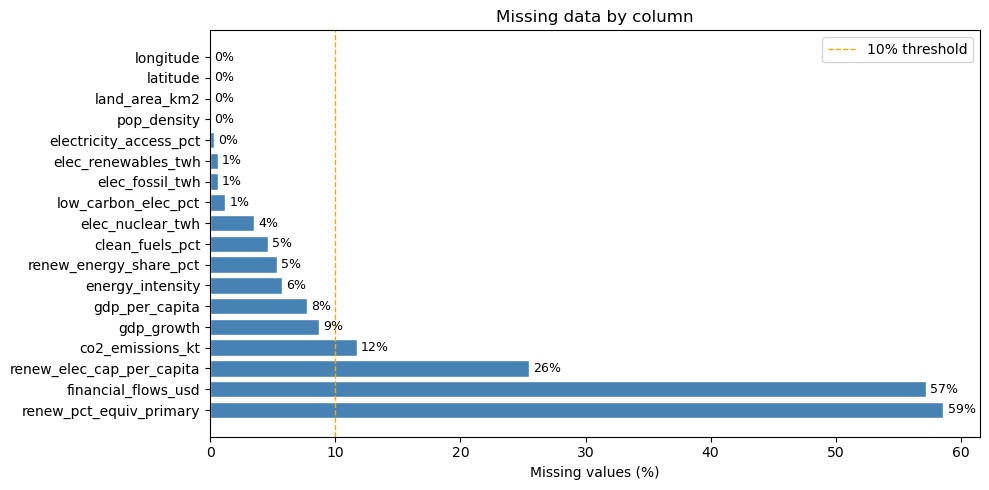

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing.index, missing['missing_pct'], color='steelblue', edgecolor='white')
ax.axvline(10, color='orange', linestyle='--', linewidth=1, label='10% threshold')
ax.set_xlabel('Missing values (%)')
ax.set_title('Missing data by column')
ax.legend()
ax.bar_label(bars, labels=[f"{v:.0f}%" for v in missing['missing_pct']], padding=3, fontsize=9)
plt.tight_layout()
plt.show()

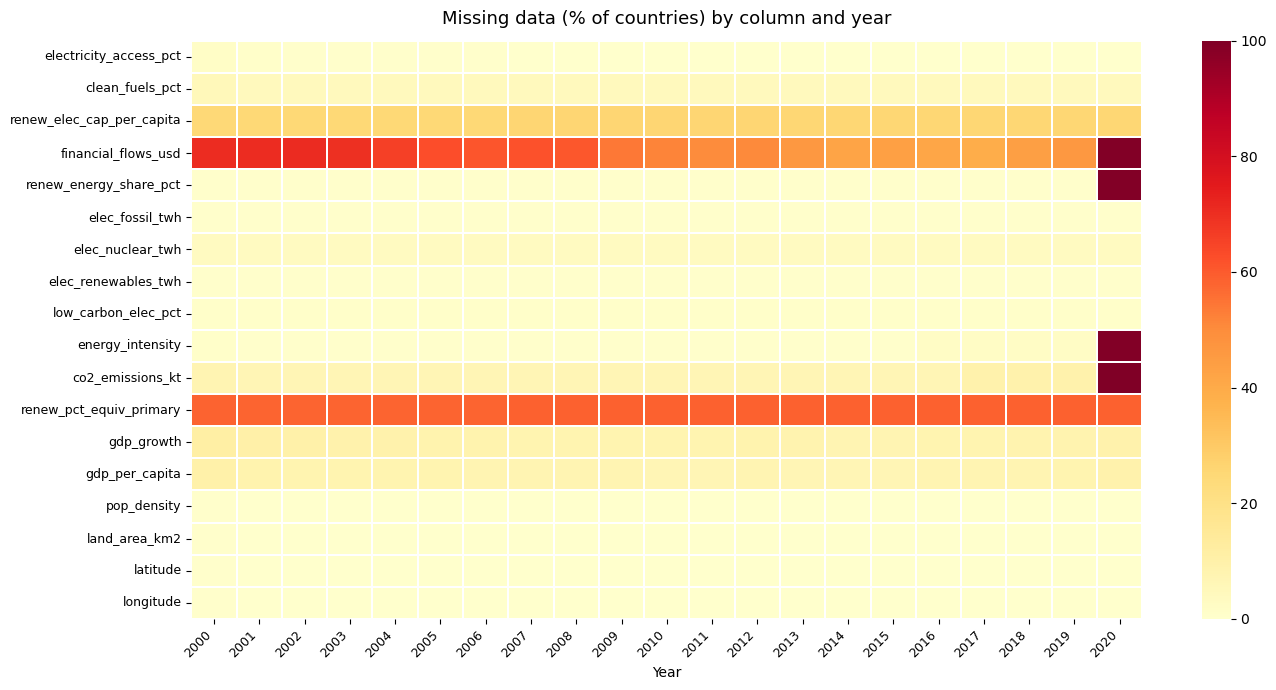

In [8]:
# Only include columns that have *any* missing values
cols_with_missing = [c for c in df.columns if df[c].isnull().any()]

heatmap_data = (
    df.groupby('year')[cols_with_missing]
      .apply(lambda g: g.isnull().mean() * 100)
      .T  # columns = years, rows = column names
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='white',
    annot=False,
    vmin=0, vmax=100,
)
ax.set_title('Missing data (% of countries) by column and year', fontsize=13, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

**Key observations from the bar chart and heatmap:**

---

**The 2020 column is almost entirely absent for several key variables.**

The heatmap reveals a sharp discontinuity in the final year: `co2_emissions_kt` is 100% missing in 2020, and `renew_energy_share_pct`, `energy_intensity`, and `financial_flows_usd` each reach ~99% missing. According to the dataset creator, this is simply because the 2020 records had not yet been collected at the time the dataset was assembled. As a result, **2020 will be excluded from any trend analysis using these columns**. Note that `renew_energy_share_pct` additionally has Albania missing across all 20 pre-2020 years, and `energy_intensity` has New Caledonia missing across all 20 pre-2020 years (plus Eritrea, South Sudan, and Yemen for 4 years each); these pre-2020 gaps are attributable to IEA reporting coverage rather than the 2020 collection cutoff.

---

**Structurally sparse columns — stable gap across all years, no improvement over time.**

- `renew_pct_equiv_primary` (~58–59% missing in every year): An IEA-specific metric that is only reported by countries submitting full energy balance data. The heatmap shows a perfectly flat band of consistent missingness — this is not a data collection gap that improved over time, but a structural feature of which countries participate in this particular reporting framework.
- `renew_elec_cap_per_capita` (~25% missing in every year, 2000–2020): Also flat in the heatmap with no improvement. The same set of ~44 countries never report this figure throughout the entire period. Imputing 20 years of values for these countries would be inappropriate.

---

**Definitionally missing — absence is meaningful, not a data problem.**

- `financial_flows_usd` (39–71% missing across years, then 99% in 2020): This column records climate finance flows *received* by developing countries. It is `NaN` for all high-income countries by design — they are donors, not recipients. The moderate improvement from ~70% missing in 2000 to ~39% in 2017 reflects more developing-country coverage over time, not improved data quality for rich nations.
- `elec_nuclear_twh` (~3.5% missing, flat across all years): The heatmap shows a perfectly uniform band — the same ~6 countries are consistently missing. Cross-checking confirms none of these countries ever record positive nuclear generation, so `NaN` here means zero output, not unreported data.

---

**Small consistent gaps — acceptable for most analyses.**

- `clean_fuels_pct` (~4.6–5.2% missing): 8 countries are missing this column across all 21 years: Aruba, Bermuda, Bulgaria, Cayman Islands, Lebanon, Libya, New Caledonia, and Puerto Rico. French Guiana adds 1 row (year 2000 only), accounting for the fractionally higher 2000 figure. The gap is stable, small, and tied to IEA cooking-fuel reporting coverage.
- `gdp_per_capita` and `gdp_growth` (7–10% missing): 22 countries have at least some missing GDP data. Of these, 12 are missing the full 21 years (e.g., Bahamas, Congo, Czechia, Egypt, Saint Kitts and Nevis, Slovakia, Yemen). The remaining 10 have partial gaps — South Sudan (missing 5 of its 8 available years), Somalia (13/21), and Nauru (10/21) being the most notable. GDP will not be imputed; the gaps are tied to real-world reporting constraints.
- `co2_emissions_kt` (~7% missing for 2000–2016, rising to ~9% in 2017–2019, then 100% in 2020): The pre-2020 gaps are concentrated in small territories below national reporting thresholds.

---

**Near-complete columns — no action needed.**

- `electricity_access_pct` (10 NaN): IEA electricity access tracking was incomplete in the early 2000s for a handful of territories: French Guiana (2000), Guinea-Bissau (2000–2001), and Liberia (2000–2006). Tracking reaches 100% from 2007 onwards.
- `elec_fossil_twh` and `elec_renewables_twh`: A flat 0.6% missing throughout — only Tuvalu is missing these values across all 21 years. Tuvalu is a micro-state whose electricity generation falls below the TWh reporting threshold; filled with 0, consistent with how the comparable territory Bermuda is stored in the raw data (genuine zeros, not NaN).
- `pop_density`, `land_area_km2`, `latitude`, `longitude`: 0.6% missing only in year 2000, corresponding to a single French Guiana row. Static geographic values imputed from reference data. Note: the raw CSV stores `pop_density` as a string with comma thousands-separators for high-density countries (e.g. `"1,265"`); commas are stripped before type conversion in §1.7, so no additional NaN are introduced.
- `low_carbon_elec_pct`: 42 NaN values remain, all belonging to Bermuda (21 rows) and Tuvalu (21 rows). Both have a recorded total electricity of zero, making the percentage mathematically undefined. These are left as NaN intentionally.

### 1.5 Handle Missing Values

We apply the strategy identified above to each column group.

In [9]:
# elec_nuclear_twh: NaN means zero nuclear generation.
# Verified: no country with NaN here ever records positive nuclear output.
nuke_nan_countries = df.loc[df['elec_nuclear_twh'].isnull(), 'country'].unique()
nuke_nonzero_countries = df.loc[df['elec_nuclear_twh'] > 0, 'country'].unique()
overlap = set(nuke_nan_countries) & set(nuke_nonzero_countries)
assert len(overlap) == 0, f"Unexpected overlap: {overlap}"

df['elec_nuclear_twh'] = df['elec_nuclear_twh'].fillna(0)

# elec_fossil_twh / elec_renewables_twh: NaN only for Tuvalu (all 21 years).
# Tuvalu is a micro-state whose electricity generation is below the TWh reporting
# threshold of this dataset. Filling with 0 is consistent with how Bermuda
# (a comparable micro-territory) is stored in the raw data.
df['elec_fossil_twh']     = df['elec_fossil_twh'].fillna(0)
df['elec_renewables_twh'] = df['elec_renewables_twh'].fillna(0)

print('NaN remaining after fill:',
      df[['elec_nuclear_twh','elec_fossil_twh','elec_renewables_twh']].isnull().sum().tolist())

NaN remaining after fill: [0, 0, 0]


**French Guiana — imputed geographic values (single row, year 2000):**

| Field | Value | Source |
|---|---|---|
| `pop_density` | 1.9 P/km² | [indexmundi.com](https://www.indexmundi.com/g/g.aspx?v=21000&c=fg&l=en) |
| `land_area_km2` | 83,534 km² | [latitude.to](https://latitude.to/map/gf/french-guiana) |
| `latitude` | 3.93° | [latitude.to](https://latitude.to/map/gf/french-guiana) |
| `longitude` | −53.09° | [latitude.to](https://latitude.to/map/gf/french-guiana) |

In [10]:
fg_mask = df['country'] == 'French Guiana'
df.loc[fg_mask, 'pop_density']   = 1.9
df.loc[fg_mask, 'land_area_km2'] = 83_534
df.loc[fg_mask, 'latitude']      = 3.93
df.loc[fg_mask, 'longitude']     = -53.09

print('French Guiana geo cols filled:')
print(df.loc[fg_mask, ['country','year','pop_density','land_area_km2','latitude','longitude']])

French Guiana geo cols filled:
            country  year pop_density  land_area_km2  latitude  longitude
1218  French Guiana  2000        1.90       83534.00      3.93     -53.09


In [11]:
# Investigate the 42 remaining NaN in low_carbon_elec_pct
nan_rows = df[df['low_carbon_elec_pct'].isnull()]

print(f'Total NaN: {len(nan_rows)}')
print(f'Countries affected: {sorted(nan_rows["country"].unique())}')
print()

# Show why: check their electricity generation totals
check = (
    nan_rows
    .groupby('country')[['elec_fossil_twh','elec_nuclear_twh','elec_renewables_twh']]
    .agg(['min','max'])
)
print('Electricity TWh range for affected countries:')
print(check)
print()
print('Conclusion: total electricity is 0 in all cases, therefore, percentage is undefined (0 ÷ 0)')

Total NaN: 42
Countries affected: ['Bermuda', 'Tuvalu']

Electricity TWh range for affected countries:
        elec_fossil_twh      elec_nuclear_twh      elec_renewables_twh     
                    min  max              min  max                 min  max
country                                                                    
Bermuda            0.00 0.00             0.00 0.00                0.00 0.00
Tuvalu             0.00 0.00             0.00 0.00                0.00 0.00

Conclusion: total electricity is 0 in all cases, therefore, percentage is undefined (0 ÷ 0)


**Decision: retain as NaN, do not fill with 0.**

Both Bermuda and Tuvalu have total electricity recorded as zero across all 21 years, so `low_carbon_elec_pct` cannot be computed. Filling with `0` would incorrectly imply these territories produce zero low-carbon electricity — which is factually wrong for Tuvalu, which operates solar installations. In practice, both are micro-territories whose electricity output falls below the TWh reporting threshold of this dataset; they will simply be excluded from any chart involving this column, which has no meaningful impact on analysis across 176 countries.

### 1.6 Check for Duplicates

In [12]:
dupes = df.duplicated(subset=['country','year'])
print(f'Duplicate (country, year) pairs: {dupes.sum()}')

# Confirm every country has at most 21 rows (2000-2020)
counts = df.groupby('country').size()
print(f'Min rows per country: {counts.min()}  Max: {counts.max()}')
print('Countries with fewer than 21 years:')
print(counts[counts < 21].sort_values())

Duplicate (country, year) pairs: 0
Min rows per country: 1  Max: 21
Countries with fewer than 21 years:
country
French Guiana     1
South Sudan       8
Montenegro       14
Serbia           14
dtype: int64


### 1.7 Data Type Verification

In [13]:
df['year'] = df['year'].astype(int)
# pop_density is stored as a string column in the raw CSV.
# High-density countries use comma thousands-separators (e.g. "1,265"); strip before converting.
df['pop_density'] = pd.to_numeric(
    df['pop_density'].astype(str).str.replace(',', ''), errors='coerce'
)
df['land_area_km2'] = pd.to_numeric(df['land_area_km2'], errors='coerce')
df.dtypes

country                       object
year                           int64
electricity_access_pct       float64
clean_fuels_pct              float64
renew_elec_cap_per_capita    float64
financial_flows_usd          float64
renew_energy_share_pct       float64
elec_fossil_twh              float64
elec_nuclear_twh             float64
elec_renewables_twh          float64
low_carbon_elec_pct          float64
primary_energy_per_capita    float64
energy_intensity             float64
co2_emissions_kt             float64
renew_pct_equiv_primary      float64
gdp_growth                   float64
gdp_per_capita               float64
pop_density                  float64
land_area_km2                float64
latitude                     float64
longitude                    float64
dtype: object

### 1.8 Add Derived Columns

A few computed columns will be useful during exploration.

In [14]:
df['elec_total_twh'] = df['elec_fossil_twh'] + df['elec_nuclear_twh'] + df['elec_renewables_twh']

df['renew_elec_share_pct'] = np.where(
    df['elec_total_twh'] > 0,
    df['elec_renewables_twh'] / df['elec_total_twh'] * 100,
    np.nan
)

# Population estimate: pop_density (P/km²) × land_area_km2
# pop_density is static in this dataset (same value for every year of a country),
# so this is a fixed proxy — it cannot reflect year-on-year population change.
df['population_est'] = df['pop_density'] * df['land_area_km2']

# CO₂ per capita (metric tonnes per person)
# co2_emissions_kt is total emissions in kilotonnes; 1 kt = 1,000 metric tonnes
# Inherits NaN wherever co2_emissions_kt is NaN (428 rows).
df['co2_per_capita'] = df['co2_emissions_kt'] * 1_000 / df['population_est']

print('Derived columns added:',
      ['elec_total_twh', 'renew_elec_share_pct', 'population_est', 'co2_per_capita'])
print('co2_per_capita sample (2019):')
sample = (df[df['year'] == 2019][['country', 'co2_per_capita']]
          .dropna()
          .sort_values('co2_per_capita', ascending=False)
          .head(10))
print(sample.to_string(index=False))

Derived columns added: ['elec_total_twh', 'renew_elec_share_pct', 'population_est', 'co2_per_capita']
co2_per_capita sample (2019):
             country  co2_per_capita
               Qatar           32.01
              Kuwait           21.67
             Bahrain           19.42
United Arab Emirates           19.14
           Australia           16.64
                Oman           15.35
        Saudi Arabia           15.23
          Luxembourg           15.16
              Canada           14.53
       United States           13.61


### 1.9 Add Continent Column

The dataset has no continent column. We derive it from the country name using `pycountry_convert`, mapping each country's ISO-2 code to one of five continent labels. North America and South America are merged into **Americas** to keep the number of groups manageable for charts.

All 176 countries in the dataset are mapped successfully.

In [15]:
import pycountry_convert as pc

_CODE_TO_CONTINENT = {
    'AF': 'Africa',
    'AS': 'Asia',
    'EU': 'Europe',
    'NA': 'Americas',
    'SA': 'Americas',
    'OC': 'Oceania',
    'AN': 'Other',
}

def _country_to_continent(name: str) -> str:
    try:
        alpha2 = pc.country_name_to_country_alpha2(name, cn_name_format='default')
        code   = pc.country_alpha2_to_continent_code(alpha2)
        return _CODE_TO_CONTINENT.get(code, 'Other')
    except Exception:
        return 'Other'

continent_lookup = {c: _country_to_continent(c) for c in df['country'].unique()}
df['continent'] = df['country'].map(continent_lookup)

unmapped = df.loc[df['continent'] == 'Other', 'country'].unique()
print('Continent distribution:')
print(df.groupby('continent')['country'].nunique().sort_values(ascending=False))
if len(unmapped):
    print(f'\nWarning — mapped to Other: {sorted(unmapped)}')
else:
    print('\nAll 176 countries mapped successfully.')

Continent distribution:
continent
Africa      50
Asia        39
Americas    38
Europe      37
Oceania     12
Name: country, dtype: int64

All 176 countries mapped successfully.


### 1.10 Summary of the Cleaned Dataset

In [16]:
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Countries: {df["country"].nunique()}')
print(f'Year range: {df["year"].min()} - {df["year"].max()}')
print()
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
print('Remaining NaN per column:')
print(remaining.to_string())

Shape: 3,649 rows x 26 columns
Countries: 176
Year range: 2000 - 2020

Remaining NaN per column:
electricity_access_pct         10
clean_fuels_pct               169
renew_elec_cap_per_capita     931
financial_flows_usd          2089
renew_energy_share_pct        194
low_carbon_elec_pct            42
energy_intensity              207
co2_emissions_kt              428
renew_pct_equiv_primary      2137
gdp_growth                    317
gdp_per_capita                282
renew_elec_share_pct           42
co2_per_capita                428


In [17]:
df.describe()

,year,electricity_access_pct,clean_fuels_pct,renew_elec_cap_per_capita,financial_flows_usd,renew_energy_share_pct,elec_fossil_twh,elec_nuclear_twh,elec_renewables_twh,low_carbon_elec_pct,primary_energy_per_capita,energy_intensity,co2_emissions_kt,renew_pct_equiv_primary,gdp_growth,gdp_per_capita,pop_density,land_area_km2,latitude,longitude,elec_total_twh,renew_elec_share_pct,population_est,co2_per_capita
count,3649.00,3639.00,3480.00,2718.00,1560.00,3455.00,3649.00,3649.00,3649.00,3607.00,3649.00,3442.00,3221.00,1512.00,3332.00,3367.00,3649.00,3649.00,3649.00,3649.00,3649.00,3607.00,3649.00,3221.00
mean,2010.04,78.93,63.26,113.14,94224000.00,32.64,69.96,12.99,23.83,36.80,25743.98,5.31,159866.46,11.99,3.44,13283.77,223.51,633062.85,18.24,14.80,106.78,32.59,42978057.46,3.95
std,6.05,30.28,39.04,244.17,298154406.59,29.89,347.09,71.78,104.15,34.31,34773.22,3.53,773661.06,14.99,5.69,19709.87,683.38,1585328.00,24.16,66.35,486.88,33.30,164674443.49,4.55
min,2000.00,1.25,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.11,10.00,0.00,-62.08,111.93,1.90,21.00,-40.90,-175.20,0.00,0.00,10218.00,0.01
25%,2005.00,59.80,23.18,3.54,260000.00,6.51,0.28,0.00,0.04,2.88,3116.74,3.17,2020.00,2.14,1.38,1337.81,34.00,25713.00,3.20,-11.78,0.89,2.29,2155205.00,0.50
50%,2010.00,98.36,83.15,32.91,5665000.00,23.30,2.94,0.00,1.42,27.87,13120.57,4.30,10500.00,6.29,3.56,4578.63,87.00,117600.00,17.19,19.15,8.68,18.57,9039663.00,2.28
75%,2015.00,100.00,100.00,112.21,55347500.00,55.25,26.52,0.00,9.56,64.40,33892.78,6.03,60580.00,16.84,5.83,15768.62,219.00,513120.00,38.97,46.20,47.74,58.53,29566208.00,6.25
max,2020.00,100.00,100.00,3060.19,5202310000.00,96.04,5184.13,809.41,2184.94,100.00,262585.70,32.57,10707219.73,86.84,123.14,123514.20,8358.00,9984670.00,64.96,178.07,7735.27,100.00,1525290032.00,32.01


**Remaining NaN after cleaning — complete accounting**

All gaps below are retained intentionally. No further imputation is applied.

| Column | NaN | Classification | Reason |
|--------|----:|---|---|
| `renew_pct_equiv_primary` | 2,137 | Structural | IEA metric; only countries submitting full energy-balance data report it. Flat ~59% all 21 years. |
| `financial_flows_usd` | 2,089 | Definitional | Records inflows to developing countries; `NaN` for all high-income donor nations by design. |
| `renew_elec_cap_per_capita` | 931 | Structural | Same 44 countries missing all 21 years; no time-trend to impute. |
| `energy_intensity` | 207 | Mixed | 174 from 2020 (not yet collected); 33 from New Caledonia (all 20 pre-2020 years), Eritrea, South Sudan, Yemen, and French Guiana. |
| `co2_emissions_kt` | 428 | Mixed | 174 from 2020; 253 pre-2020 for countries below national reporting thresholds. |
| `co2_per_capita` | 428 | Derived | Derived from `co2_emissions_kt`; inherits the same NaN. |
| `gdp_growth` | 317 | Reporting gap | World Bank data absent for the same countries as `gdp_per_capita`, plus additional partial gaps. |
| `gdp_per_capita` | 282 | Reporting gap | 12 countries with no World Bank records at all; 10 with partial gaps. |
| `renew_energy_share_pct` | 194 | Mixed | 174 from 2020; 20 from Albania missing all 20 pre-2020 years. |
| `clean_fuels_pct` | 169 | Structural | 8 countries missing all 21 years: Aruba, Bermuda, Bulgaria, Cayman Islands, Lebanon, Libya, New Caledonia, Puerto Rico; plus French Guiana (1 row). |
| `low_carbon_elec_pct` | 42 | Undefined | Bermuda and Tuvalu: `elec_total_twh = 0`; percentage is mathematically undefined (0 ÷ 0). |
| `renew_elec_share_pct` | 42 | Derived | Derived column; inherits NaN from same Bermuda + Tuvalu rows. |
| `electricity_access_pct` | 10 | Early tracking | French Guiana (2000), Guinea-Bissau (2000–2001), Liberia (2000–2006); IEA tracking reaches 100% from 2007. |

### 1.11 Save the Refined Dataset

In [18]:
output_path = 'global-data-on-sustainable-energy-cleaned.csv'
df.to_csv(output_path, index=False)
print(f'Saved: {output_path}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

Saved: global-data-on-sustainable-energy-cleaned.csv
Shape: 3,649 rows x 26 columns


---
## Section 2 — Exploring the Refined Dataset

The cleaned dataset (176 countries, 2000–2020, 26 columns) is explored through 20 charts organised into three thematic parts:

1. **Energy Equity** — access to electricity and clean cooking fuels across countries and time
2. **Energy Structure** — electricity generation mix, efficiency trends, and finance flows
3. **Carbon Emissions** — CO₂ patterns and their relationship to development and energy choices

In [19]:
import os

CONT_PALETTE = {
    'Africa':   '#E07B39',
    'Americas': '#4D9BE6',
    'Asia':     '#6BBF59',
    'Europe':   '#9B6BB5',
    'Oceania':  '#E6C84D',
}
CONT_ORDER = ['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']

import pycountry

# Manual overrides for names that pycountry.search_fuzzy() cannot resolve
_ISO3_OVERRIDES = {'Turkey': 'TUR'}

def _get_iso3(name: str):
    if name in _ISO3_OVERRIDES:
        return _ISO3_OVERRIDES[name]
    try:
        return pycountry.countries.search_fuzzy(name)[0].alpha_3
    except Exception:
        return None

_iso3_map = {c: _get_iso3(c) for c in df['country'].unique()}
_failed   = [c for c, v in _iso3_map.items() if v is None]
df['iso3'] = df['country'].map(_iso3_map)
print(f'ISO-3 codes assigned. Failures: {_failed if _failed else "none"}')

# ── Global Matplotlib / Seaborn style ────────────────────────────────────────
plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.titlepad':    12,
    'axes.labelsize':   11,
    'axes.labelpad':    6,
    'axes.grid':        True,
    'grid.color':       '#E8E8E8',
    'grid.linestyle':   '-',
    'grid.linewidth':   0.8,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'legend.fontsize':  10,
    'legend.frameon':   False,
    'figure.dpi':       120,
    'savefig.dpi':      150,
    'savefig.bbox':     'tight',
})

os.makedirs('images', exist_ok=True)
print('Output folder ready: images/')

ISO-3 codes assigned. Failures: none
Output folder ready: images/


### Part 1 — Energy Equity

**Chart 1 — How has the geographic distribution of electricity access changed globally from 2000 to 2020?**

An animated choropleth maps `electricity_access_pct` for all 176 countries across 21 years, making the spatial pattern and its change over time immediately visible. ISO alpha-3 country codes are used for reliable Plotly matching.

In [20]:
df_c1 = (df[df['electricity_access_pct'].notna() & df['iso3'].notna()]
         .sort_values('year'))

fig = px.choropleth(
    df_c1,
    locations='iso3',
    color='electricity_access_pct',
    animation_frame='year',
    hover_name='country',
    color_continuous_scale='YlOrRd',
    range_color=[0, 100],
    projection='natural earth',
    title='Chart 1 — Electricity Access (% of Population), 2000–2020',
    labels={'electricity_access_pct': 'Access (%)'},
)
fig.update_layout(
    coloraxis_colorbar=dict(title='Access (%)', thickness=14, len=0.7),
    margin=dict(l=0, r=0, t=55, b=0),
    height=500,
    title_font_size=15,
    title_x=0.5,
)
fig.write_html('images/chart01_electricity_access_map.html')
print('Saved: images/chart01_electricity_access_map.html')
fig.show()

Saved: images/chart01_electricity_access_map.html


**Chart 2 — Have global average electricity access and clean cooking fuel access risen in tandem over 20 years?**

Both columns are aggregated to global means per year and plotted as two lines. The shaded area between them shows the persistent access gap. The aggregated data is also exported as a CSV for the Datawrapper version of this chart on the web page.

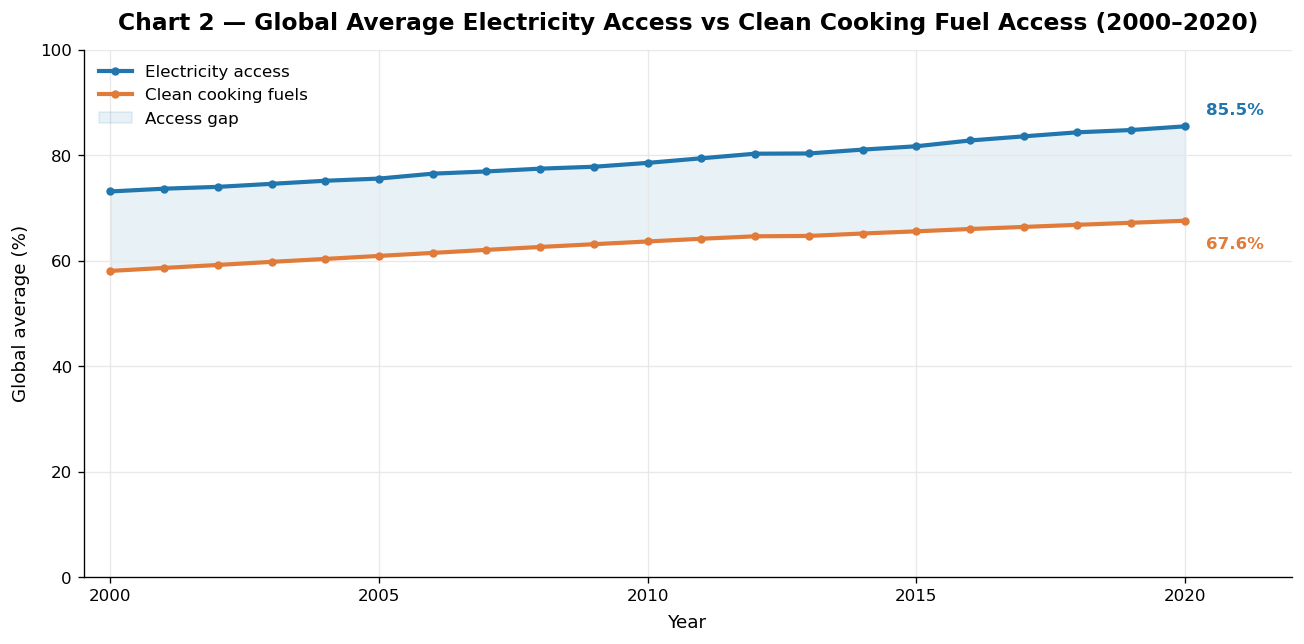

Saved: images/chart02_energy_access_trend.png
Exported: chart2_datawrapper.csv


In [21]:
trend = df.groupby('year')[['electricity_access_pct', 'clean_fuels_pct']].mean()

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(trend.index, trend['electricity_access_pct'],
        color='#2176AE', lw=2.5, marker='o', ms=4, label='Electricity access')
ax.plot(trend.index, trend['clean_fuels_pct'],
        color='#E07B39', lw=2.5, marker='o', ms=4, label='Clean cooking fuels')
ax.fill_between(trend.index, trend['clean_fuels_pct'], trend['electricity_access_pct'],
                alpha=0.10, color='#2176AE', label='Access gap')

# Annotate 2020 end-point values
for col, color, y_offset in [
    ('electricity_access_pct', '#2176AE',  3.0),
    ('clean_fuels_pct',        '#E07B39', -4.5),
]:
    val = trend.loc[2020, col]
    ax.annotate(f'{val:.1f}%', xy=(2020, val),
                xytext=(2020.4, val + y_offset),
                fontsize=10, color=color, fontweight='bold', ha='left', va='center')

ax.set_xlabel('Year')
ax.set_ylabel('Global average (%)')
ax.set_title('Chart 2 — Global Average Electricity Access vs Clean Cooking Fuel Access (2000–2020)')
ax.set_xlim(1999.5, 2022)
ax.set_ylim(0, 100)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.legend(loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/chart02_energy_access_trend.png')
plt.show()

# Export for Datawrapper — upload chart2_datawrapper.csv to produce the web version
(trend.reset_index()
      .rename(columns={'electricity_access_pct': 'Electricity access (%)',
                       'clean_fuels_pct':         'Clean cooking fuels (%)'})
      .to_csv('chart2_datawrapper.csv', index=False))
print('Saved: images/chart02_energy_access_trend.png')
print('Exported: chart2_datawrapper.csv')

**Chart 3 — In 2020, does having electricity imply having clean cooking energy?**

Each point is one country in 2020, coloured by continent. A single OLS regression line across all countries shows the overall relationship. Countries clustered at 100% electricity access but varying clean-fuel levels reveal that electrification alone does not guarantee cooking energy access.

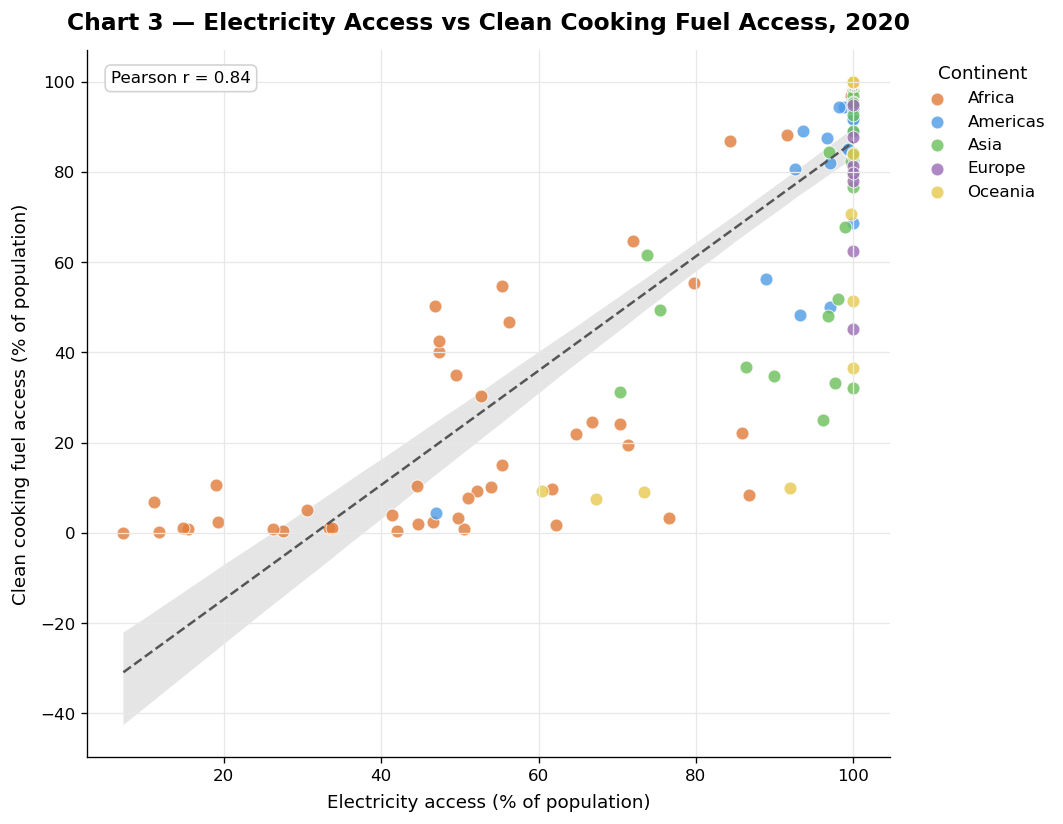

Saved: images/chart03_electricity_vs_clean_fuels.png


In [22]:
df_c3 = df[df['year'] == 2020].dropna(subset=['electricity_access_pct', 'clean_fuels_pct'])

fig, ax = plt.subplots(figsize=(9, 7))

# Overall regression line (all countries combined)
sns.regplot(data=df_c3, x='electricity_access_pct', y='clean_fuels_pct',
            scatter=False, ax=ax,
            line_kws={'color': '#555555', 'lw': 1.5, 'linestyle': '--'})

# Scatter coloured by continent
for cont in CONT_ORDER:
    grp = df_c3[df_c3['continent'] == cont]
    ax.scatter(grp['electricity_access_pct'], grp['clean_fuels_pct'],
               color=CONT_PALETTE[cont], alpha=0.80, s=60,
               label=cont, edgecolors='white', linewidths=0.6)

# Pearson r (numpy)
r = np.corrcoef(df_c3['electricity_access_pct'], df_c3['clean_fuels_pct'])[0, 1]
ax.text(0.03, 0.97, f'Pearson r = {r:.2f}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='#CCCCCC', alpha=0.85))

ax.set_xlabel('Electricity access (% of population)')
ax.set_ylabel('Clean cooking fuel access (% of population)')
ax.set_title('Chart 3 — Electricity Access vs Clean Cooking Fuel Access, 2020')
ax.legend(title='Continent', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/chart03_electricity_vs_clean_fuels.png')
plt.show()
print('Saved: images/chart03_electricity_vs_clean_fuels.png')

**Chart 4 — How has average electricity access evolved by continent over 20 years? Which continent grew fastest?**

Small multiples with one subplot per continent allow direct comparison of trajectories while a shared y-axis keeps the scale honest. Africa's steep climb is visible against the near-flat lines of Europe and the Americas, which were already close to universal access in 2000.

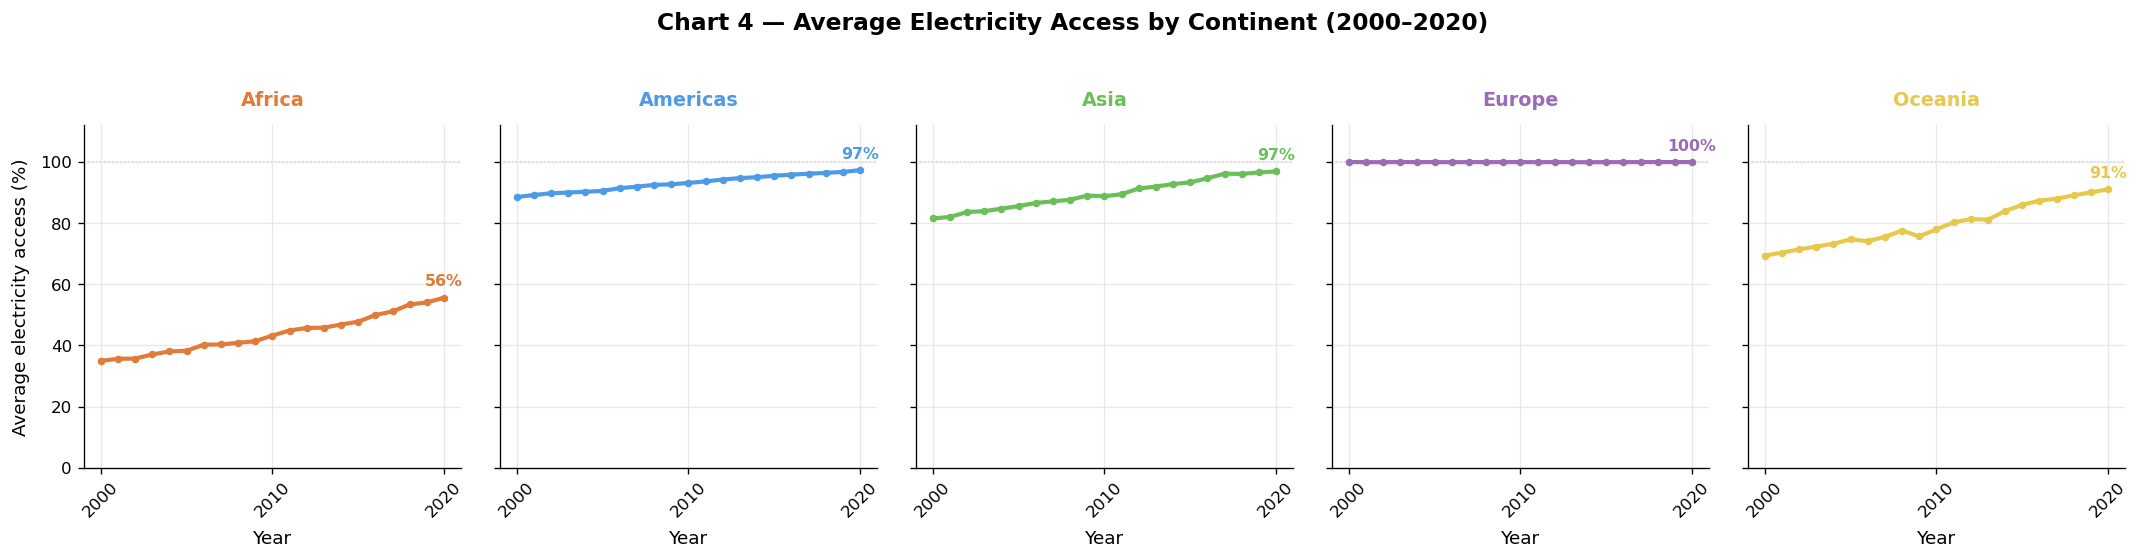

Saved: images/chart04_access_by_continent.png


In [23]:
trend_cont = (df.groupby(['year', 'continent'])['electricity_access_pct']
               .mean().reset_index())

fig, axes = plt.subplots(1, 5, figsize=(18, 4.5), sharey=True)
fig.suptitle('Chart 4 — Average Electricity Access by Continent (2000–2020)',
             fontsize=14, fontweight='bold', y=1.03)

for ax, cont in zip(axes, CONT_ORDER):
    data = trend_cont[trend_cont['continent'] == cont]
    ax.plot(data['year'], data['electricity_access_pct'],
            color=CONT_PALETTE[cont], lw=2.5, marker='o', ms=3.5)
    # Reference line at 100%
    ax.axhline(100, color='#BBBBBB', lw=0.9, linestyle=':', zorder=0)
    # Annotate 2020 endpoint
    val_2020 = data.loc[data['year'] == 2020, 'electricity_access_pct'].values
    if len(val_2020):
        ax.annotate(f'{val_2020[0]:.0f}%', xy=(2020, val_2020[0]),
                    xytext=(0, 7), textcoords='offset points',
                    ha='center', fontsize=9.5, color=CONT_PALETTE[cont], fontweight='bold')
    ax.set_title(cont, fontsize=11.5, fontweight='bold', color=CONT_PALETTE[cont])
    ax.set_ylim(0, 112)
    ax.set_xlabel('Year')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
    ax.tick_params(axis='x', rotation=45)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Average electricity access (%)')
plt.tight_layout()
plt.savefig('images/chart04_access_by_continent.png')
plt.show()
print('Saved: images/chart04_access_by_continent.png')

**Chart 5 — Has within-continent variation in electricity access narrowed as mean access improved?**

Four snapshot years (2000, 2007, 2014, 2020) are shown as grouped box plots, one group per continent. A narrowing interquartile range over time within a continent signals convergence — countries previously left behind are catching up with their regional peers.

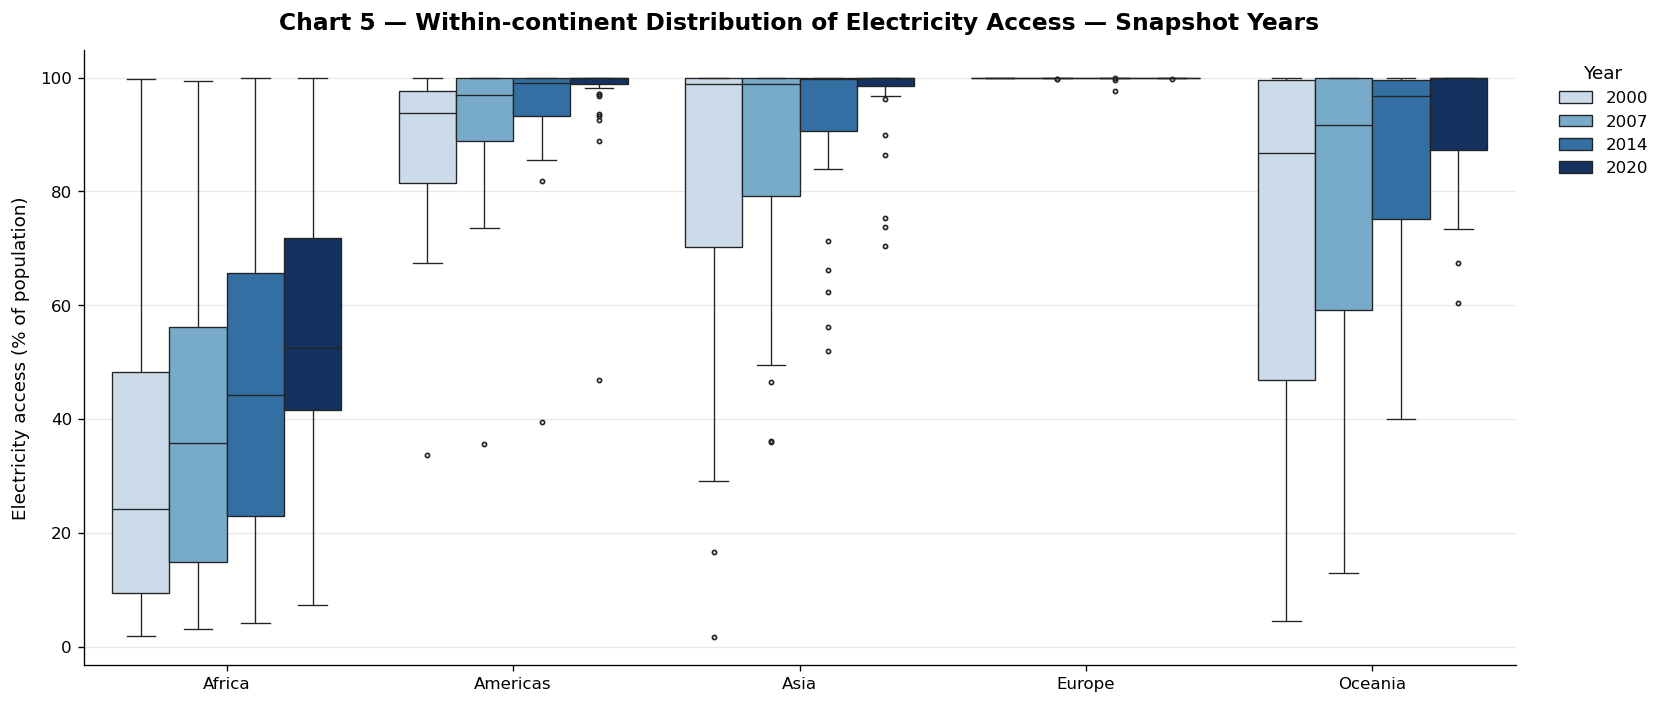

Saved: images/chart05_access_distribution.png


In [24]:
snap_years = [2000, 2007, 2014, 2020]
df_c5 = df[df['year'].isin(snap_years)].copy()
df_c5['Year'] = df_c5['year'].astype(str)   # string so seaborn treats hue as categorical

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=df_c5, x='continent', y='electricity_access_pct', hue='Year',
    order=CONT_ORDER,
    palette={'2000': '#c6dbef', '2007': '#6baed6', '2014': '#2171b5', '2020': '#08306b'},
    linewidth=0.8, fliersize=2.5, ax=ax,
)
ax.set_xlabel('')
ax.set_ylabel('Electricity access (% of population)')
ax.set_title('Chart 5 — Within-continent Distribution of Electricity Access — Snapshot Years')
ax.legend(title='Year', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/chart05_access_distribution.png')
plt.show()
print('Saved: images/chart05_access_distribution.png')

**Chart 6 — In 2020, where are the 20 countries with the lowest electricity access, and what do they have in common?**

Filtered to the 20 countries with the lowest `electricity_access_pct` in 2020 that also have GDP data. The x-axis shows GDP per capita, y-axis shows electricity access, and bubble size encodes population density. Countries are labelled directly and coloured by continent.

Bottom 20 countries: ['Chad', 'Burundi', 'Malawi', 'Central African Republic', 'Burkina Faso', 'Niger', 'Sierra Leone', 'Liberia', 'Mozambique', 'Guinea-Bissau', 'Madagascar', 'Benin', 'Uganda', 'Zambia', 'Guinea', 'Rwanda', 'Angola', 'Haiti', 'Mauritania', 'Lesotho']
Continents represented: {'Africa': 19, 'Americas': 1}


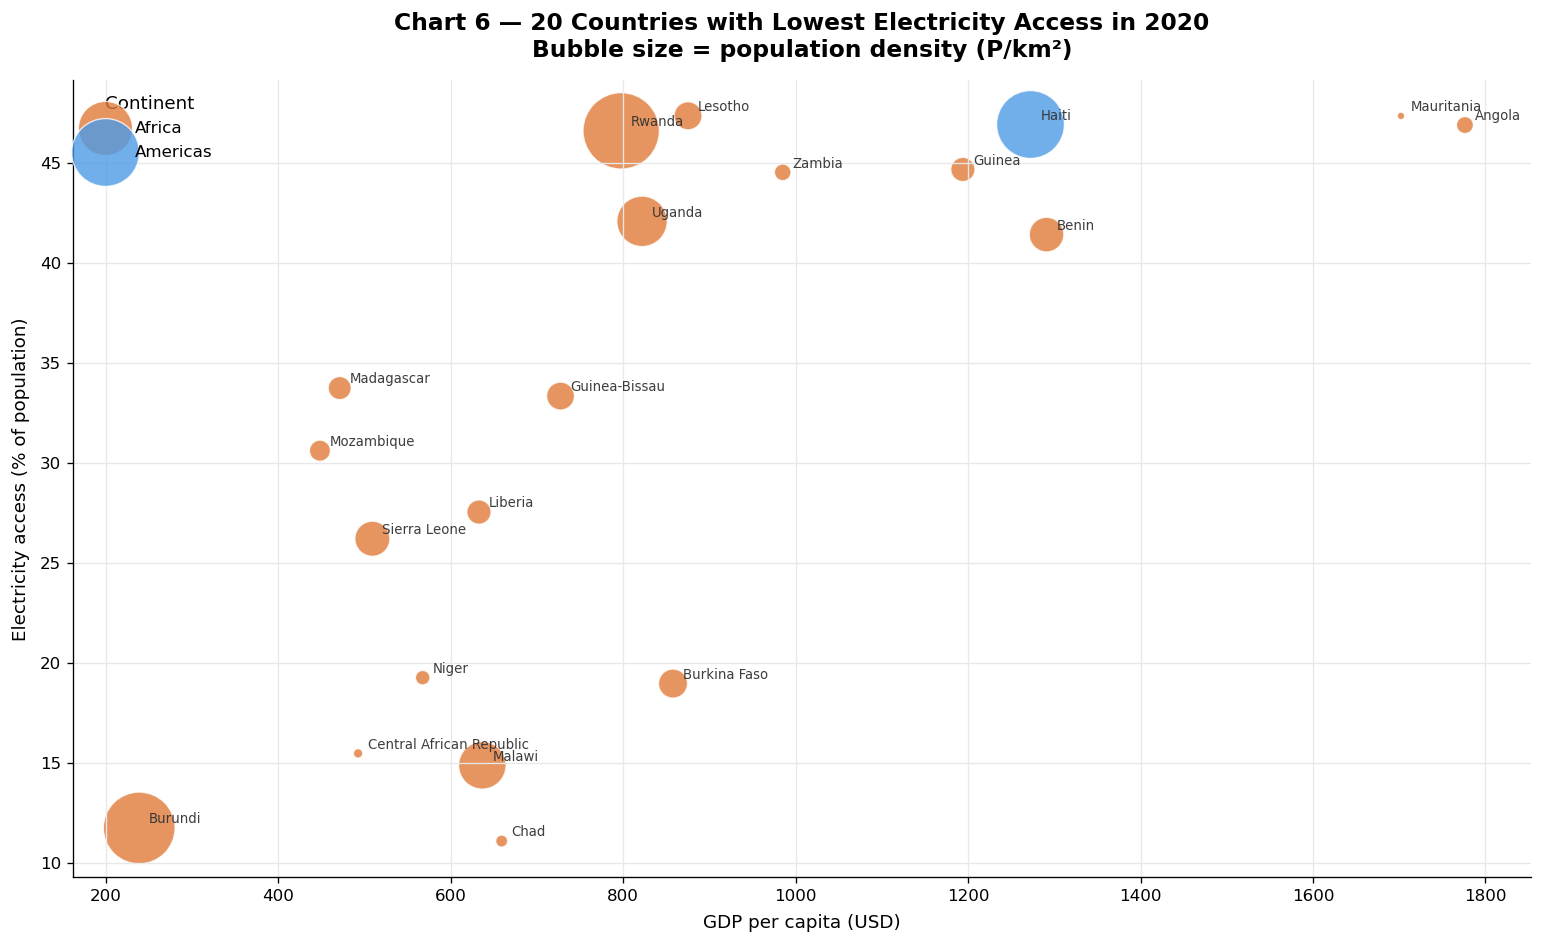

Saved: images/chart06_low_access_bubble.png


In [25]:
df_c6 = (df[df['year'] == 2020]
         .dropna(subset=['electricity_access_pct', 'gdp_per_capita', 'pop_density'])
         .nsmallest(20, 'electricity_access_pct'))

print(f'Bottom 20 countries: {df_c6["country"].tolist()}')
print(f'Continents represented: {df_c6["continent"].value_counts().to_dict()}')

fig, ax = plt.subplots(figsize=(13, 8))

for cont in CONT_ORDER:
    grp = df_c6[df_c6['continent'] == cont]
    if grp.empty:
        continue
    ax.scatter(
        grp['gdp_per_capita'], grp['electricity_access_pct'],
        s=grp['pop_density'] * 4,
        color=CONT_PALETTE[cont], alpha=0.80,
        label=cont, edgecolors='white', linewidths=0.8,
    )

# Country labels
for _, row in df_c6.iterrows():
    ax.annotate(row['country'],
                xy=(row['gdp_per_capita'], row['electricity_access_pct']),
                fontsize=8, xytext=(6, 3), textcoords='offset points',
                alpha=0.95, color='#333333')

ax.set_xlabel('GDP per capita (USD)')
ax.set_ylabel('Electricity access (% of population)')
ax.set_title('Chart 6 — 20 Countries with Lowest Electricity Access in 2020\n'
             'Bubble size = population density (P/km²)', pad=14)
ax.legend(title='Continent', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/chart06_low_access_bubble.png')
plt.show()
print('Saved: images/chart06_low_access_bubble.png')

---

### Part 2 — Energy Structure

Charts 7–13 examine how electricity is generated globally and by continent, how efficiently energy is used, where international climate finance flows, and whether renewable capacity correlates with renewable share.

**Chart 7 — How has the global electricity generation mix evolved from 2000 to 2020?**

A stacked area chart of cumulative global TWh by source — fossil, nuclear, and renewables. The renewables band grows visibly from ~2010, while the nuclear share remains nearly flat and total generation rises steadily driven by fossil fuels.

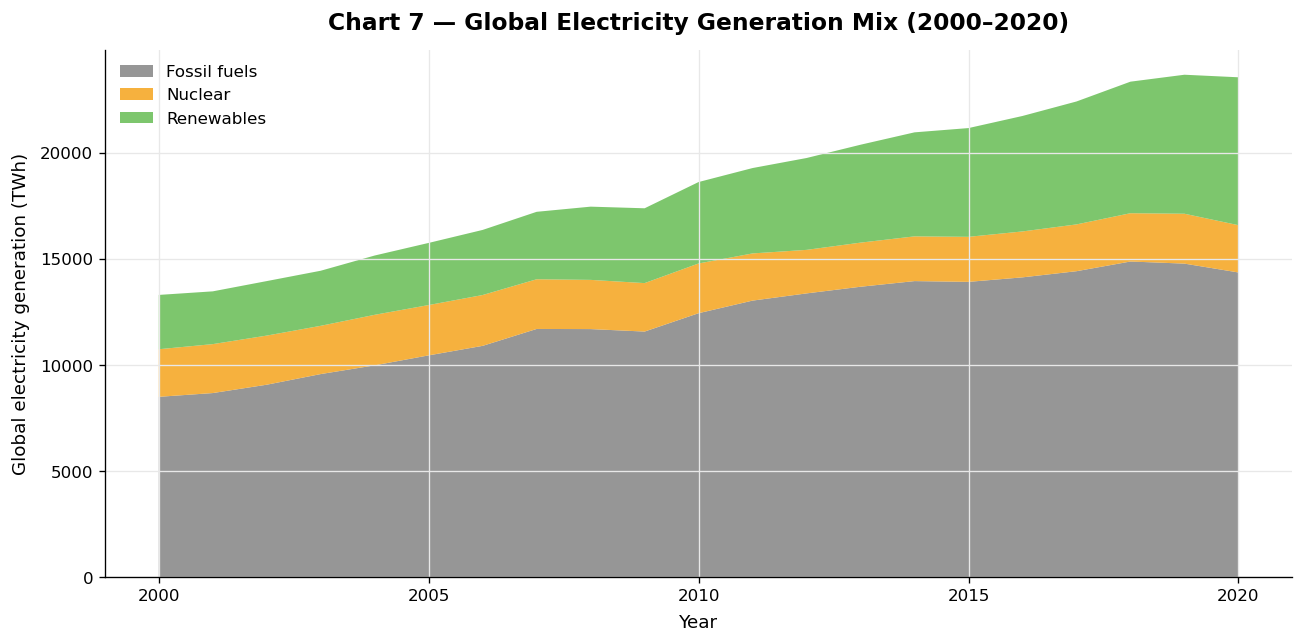

Saved: images/chart07_global_electricity_mix.png


In [26]:
mix = df.groupby('year')[['elec_fossil_twh', 'elec_nuclear_twh', 'elec_renewables_twh']].sum()

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.stackplot(
    mix.index,
    mix['elec_fossil_twh'], mix['elec_nuclear_twh'], mix['elec_renewables_twh'],
    labels=['Fossil fuels', 'Nuclear', 'Renewables'],
    colors=['#888888', '#F5A623', '#6BBF59'],
    alpha=0.88,
)
ax.set_xlabel('Year')
ax.set_ylabel('Global electricity generation (TWh)')
ax.set_title('Chart 7 — Global Electricity Generation Mix (2000–2020)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.legend(loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/chart07_global_electricity_mix.png')
plt.show()
print('Saved: images/chart07_global_electricity_mix.png')

**Chart 8 — How does the 2020 electricity mix differ by continent? Who is most fossil-dependent?**

Each bar shows one continent's total 2020 generation normalised to 100%. Percentage labels appear on segments wider than 5 pp. Asia and Americas carry the highest fossil shares; Europe leads in nuclear; Africa and Americas show notable renewable shares.

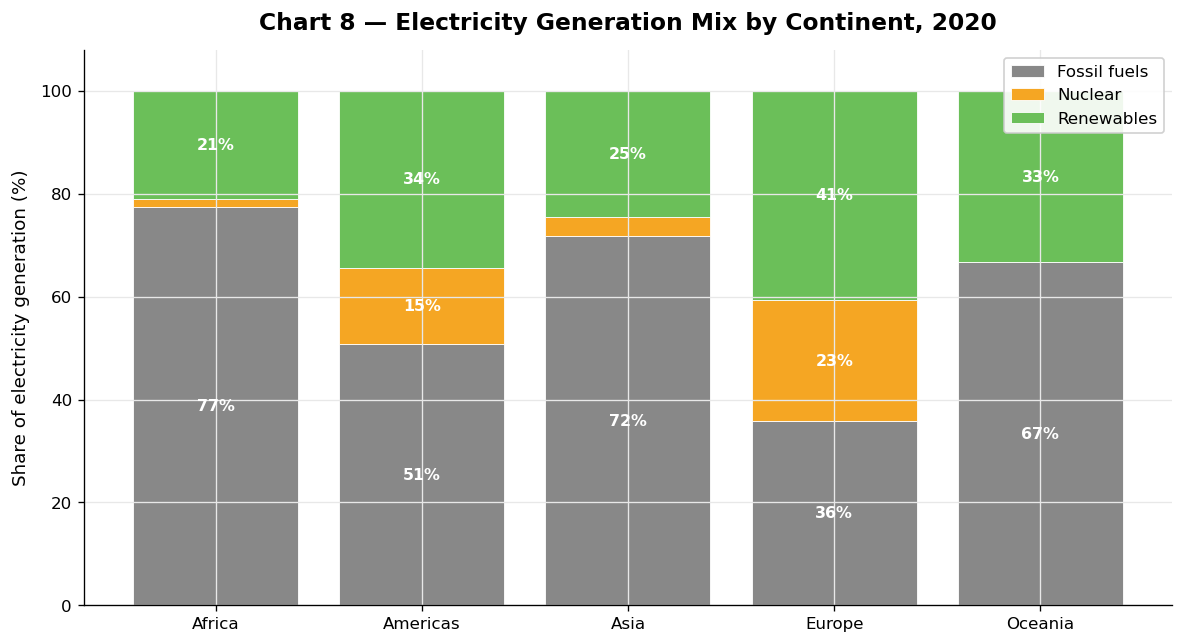

Saved: images/chart08_mix_by_continent.png


In [27]:
mix_cont = (
    df[df['year'] == 2020]
    .groupby('continent')[['elec_fossil_twh', 'elec_nuclear_twh', 'elec_renewables_twh']]
    .sum()
    .reindex(CONT_ORDER)
)
mix_pct = mix_cont.div(mix_cont.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5.5))
bottom = np.zeros(len(CONT_ORDER))
for col, color, label in [
    ('elec_fossil_twh',     '#888888', 'Fossil fuels'),
    ('elec_nuclear_twh',    '#F5A623', 'Nuclear'),
    ('elec_renewables_twh', '#6BBF59', 'Renewables'),
]:
    vals = mix_pct[col].values
    ax.bar(CONT_ORDER, vals, bottom=bottom, color=color, label=label,
           edgecolor='white', linewidth=0.5)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax.text(i, b + v / 2, f'{v:.0f}%',
                    ha='center', va='center', fontsize=9.5,
                    color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel('Share of electricity generation (%)')
ax.set_title('Chart 8 — Electricity Generation Mix by Continent, 2020')
ax.set_ylim(0, 108)
ax.legend(loc='upper right', frameon=True, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/chart08_mix_by_continent.png')
plt.show()
print('Saved: images/chart08_mix_by_continent.png')

**Chart 9 — Which 10 countries had the highest renewable electricity share in 2020?**

A minimum threshold of 1 TWh total generation filters out micro-states whose tiny absolute output is trivially 100 % renewable (e.g. Central African Republic, 0.15 TWh). The resulting top-10 includes small hydro-dominant nations (Albania, Bhutan, Nepal) alongside well-known clean-energy leaders (Iceland, Norway, Costa Rica).

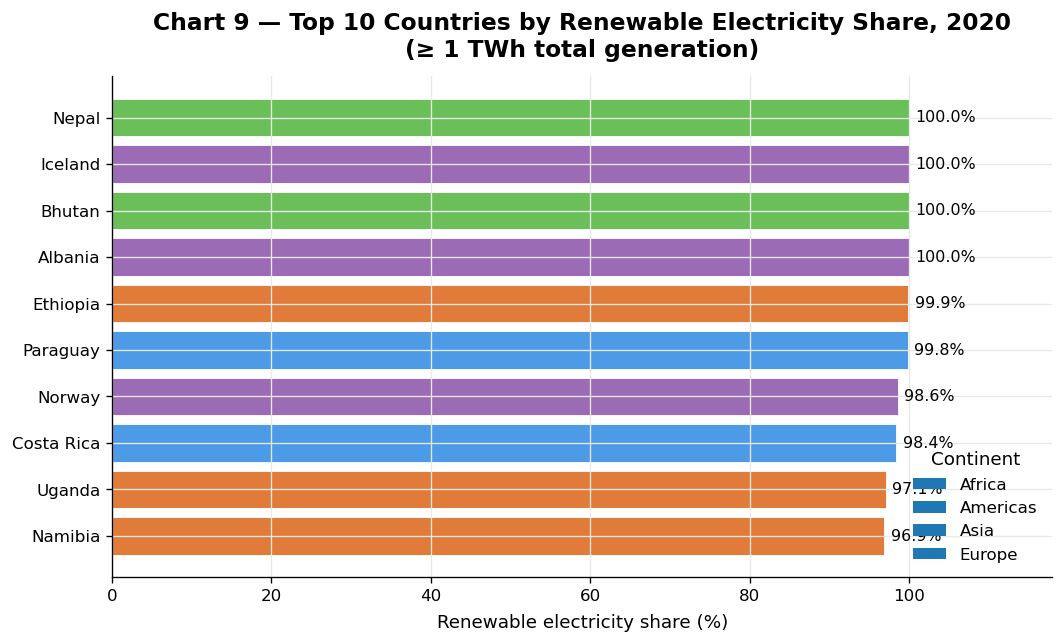

Saved: images/chart09_top10_renewable_share.png


In [28]:
df_c9 = (
    df[(df['year'] == 2020) & (df['elec_total_twh'] >= 1)]
    .dropna(subset=['renew_elec_share_pct'])
    .nlargest(10, 'renew_elec_share_pct')
    .sort_values('renew_elec_share_pct')
)

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = [CONT_PALETTE[c] for c in df_c9['continent']]
bars = ax.barh(df_c9['country'], df_c9['renew_elec_share_pct'],
               color=colors, edgecolor='white', linewidth=0.5)
ax.bar_label(bars, labels=[f'{v:.1f}%' for v in df_c9['renew_elec_share_pct']],
             padding=4, fontsize=9.5)
for cont in CONT_ORDER:
    if cont in df_c9['continent'].values:
        ax.barh([], [], color=CONT_PALETTE[cont], label=cont)

ax.legend(title='Continent', loc='lower right')
ax.set_xlabel('Renewable electricity share (%)')
ax.set_title('Chart 9 — Top 10 Countries by Renewable Electricity Share, 2020\n(≥ 1 TWh total generation)')
ax.set_xlim(0, 118)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/chart09_top10_renewable_share.png')
plt.show()
print('Saved: images/chart09_top10_renewable_share.png')

**Chart 10 — How has energy intensity changed by continent from 2000 to 2019? Is efficiency improving?**

Energy intensity (MJ per dollar of PPP GDP) declines as economies become more efficient or shift toward less energy-intensive industries. 2020 is excluded (near-complete data gap for this column). Asia's steep decline is the standout story; Africa remains highest throughout, reflecting persistent structural inefficiency.

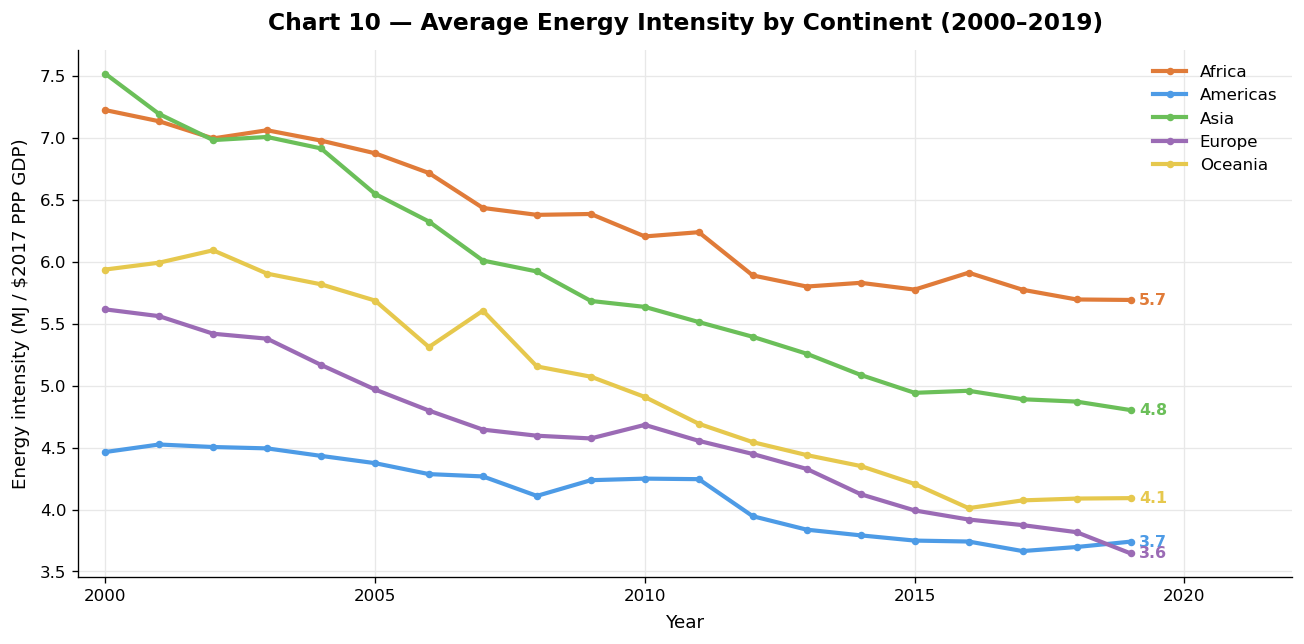

Saved: images/chart10_energy_intensity_trend.png


In [29]:
ei_cont = (
    df[df['year'] <= 2019]
    .groupby(['year', 'continent'])['energy_intensity']
    .mean().reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5.5))
for cont in CONT_ORDER:
    data = ei_cont[ei_cont['continent'] == cont]
    ax.plot(data['year'], data['energy_intensity'],
            color=CONT_PALETTE[cont], lw=2.5, marker='o', ms=3.5, label=cont)
    val = data.loc[data['year'] == 2019, 'energy_intensity'].values
    if len(val):
        ax.annotate(f'{val[0]:.1f}', xy=(2019, val[0]),
                    xytext=(5, 0), textcoords='offset points',
                    fontsize=9.5, color=CONT_PALETTE[cont], va='center', fontweight='bold')

ax.set_xlabel('Year')
ax.set_ylabel('Energy intensity (MJ / $2017 PPP GDP)')
ax.set_title('Chart 10 — Average Energy Intensity by Continent (2000–2019)')
ax.set_xlim(1999.5, 2022)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.legend(loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/chart10_energy_intensity_trend.png')
plt.show()
print('Saved: images/chart10_energy_intensity_trend.png')

**Chart 11 — Does higher renewable energy share correlate with lower energy intensity in 2019?**

Economy-wide renewable share (`renew_energy_share_pct`) is paired with energy intensity — both cover the full economy rather than the electricity sector alone, making the comparison conceptually consistent. A negative correlation is expected: countries deriving more energy from renewables typically have lower per-GDP energy consumption.

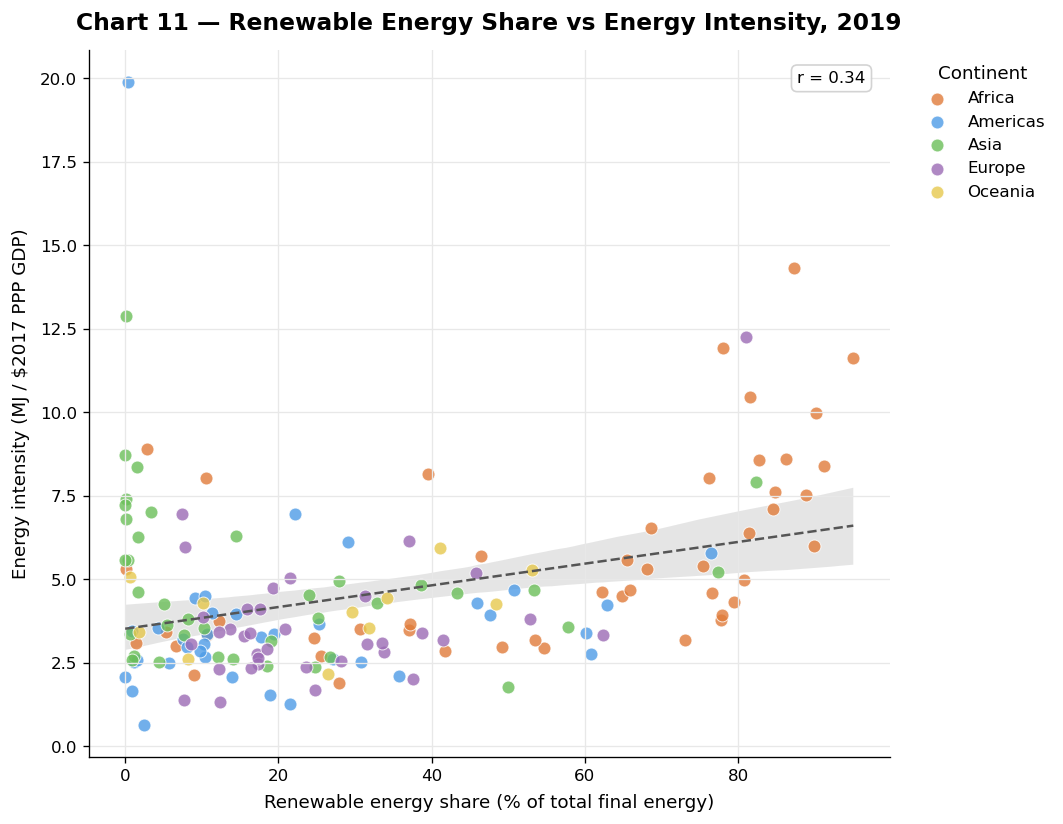

Saved: images/chart11_renewable_vs_intensity.png


In [30]:
df_c11 = df[df['year'] == 2019].dropna(subset=['renew_energy_share_pct', 'energy_intensity'])

fig, ax = plt.subplots(figsize=(9, 7))
sns.regplot(data=df_c11, x='renew_energy_share_pct', y='energy_intensity',
            scatter=False, ax=ax,
            line_kws={'color': '#555555', 'lw': 1.5, 'linestyle': '--'})
for cont in CONT_ORDER:
    grp = df_c11[df_c11['continent'] == cont]
    ax.scatter(grp['renew_energy_share_pct'], grp['energy_intensity'],
               color=CONT_PALETTE[cont], alpha=0.80, s=60, label=cont,
               edgecolors='white', linewidths=0.6)

r = np.corrcoef(df_c11['renew_energy_share_pct'], df_c11['energy_intensity'])[0, 1]
ax.text(0.97, 0.97, f'r = {r:.2f}', transform=ax.transAxes,
        fontsize=10, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='#CCCCCC', alpha=0.85))

ax.set_xlabel('Renewable energy share (% of total final energy)')
ax.set_ylabel('Energy intensity (MJ / $2017 PPP GDP)')
ax.set_title('Chart 11 — Renewable Energy Share vs Energy Intensity, 2019')
ax.legend(title='Continent', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/chart11_renewable_vs_intensity.png')
plt.show()
print('Saved: images/chart11_renewable_vs_intensity.png')

**Chart 12 — How have international clean energy financial flows to developing countries changed over 20 years?**

Stacked by recipient continent (2000–2019; 2020 excluded). `financial_flows_usd` is only reported for developing countries that *receive* climate finance — high-income donor nations are excluded by design. The chart reveals which regions attract the most capital and how the total has grown over the two decades.

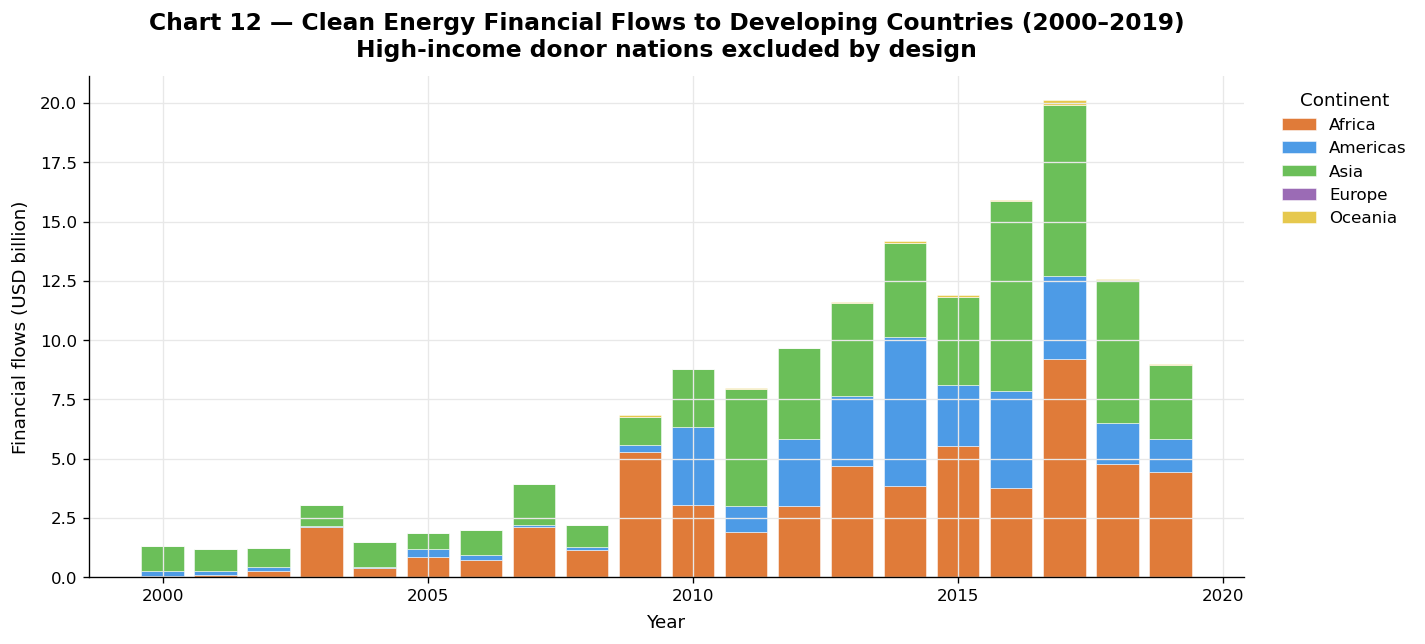

Saved: images/chart12_financial_flows.png


In [31]:
df_c12 = df[(df['year'] <= 2019) & df['financial_flows_usd'].notna()]
flows = (
    df_c12.groupby(['year', 'continent'])['financial_flows_usd']
    .sum()
    .unstack('continent')
    .reindex(columns=CONT_ORDER)
    .fillna(0)
    / 1e9
)

fig, ax = plt.subplots(figsize=(12, 5.5))
bottom = np.zeros(len(flows))
for cont in CONT_ORDER:
    if cont in flows.columns:
        vals = flows[cont].values
        ax.bar(flows.index, vals, bottom=bottom,
               color=CONT_PALETTE[cont], label=cont, edgecolor='white', linewidth=0.3)
        bottom += vals

ax.set_xlabel('Year')
ax.set_ylabel('Financial flows (USD billion)')
ax.set_title(
    'Chart 12 — Clean Energy Financial Flows to Developing Countries (2000–2019)\n'
    'High-income donor nations excluded by design'
)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.legend(title='Continent', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/chart12_financial_flows.png')
plt.show()
print('Saved: images/chart12_financial_flows.png')

**Chart 13 — In 2020, is higher renewable electricity capacity per capita associated with higher renewable electricity share?**

Capacity per person indicates investment but share also depends on total electricity demand. Countries with modest absolute capacity but low overall consumption (e.g. small hydro nations in Africa/Asia) can still achieve high shares, creating scatter above the regression line.

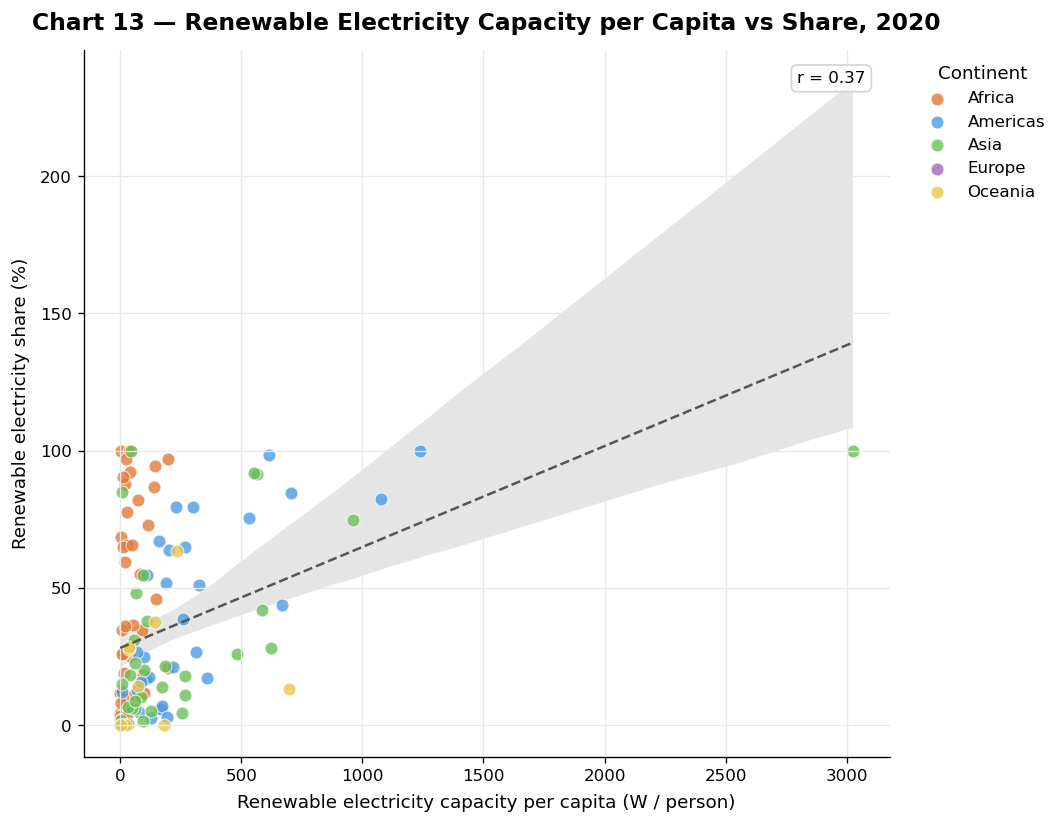

Saved: images/chart13_renew_capacity_vs_share.png


In [32]:
df_c13 = df[df['year'] == 2020].dropna(subset=['renew_elec_cap_per_capita', 'renew_elec_share_pct'])

fig, ax = plt.subplots(figsize=(9, 7))
sns.regplot(data=df_c13, x='renew_elec_cap_per_capita', y='renew_elec_share_pct',
            scatter=False, ax=ax,
            line_kws={'color': '#555555', 'lw': 1.5, 'linestyle': '--'})
for cont in CONT_ORDER:
    grp = df_c13[df_c13['continent'] == cont]
    ax.scatter(grp['renew_elec_cap_per_capita'], grp['renew_elec_share_pct'],
               color=CONT_PALETTE[cont], alpha=0.80, s=60, label=cont,
               edgecolors='white', linewidths=0.6)

r = np.corrcoef(df_c13['renew_elec_cap_per_capita'], df_c13['renew_elec_share_pct'])[0, 1]
ax.text(0.97, 0.97, f'r = {r:.2f}', transform=ax.transAxes,
        fontsize=10, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='#CCCCCC', alpha=0.85))

ax.set_xlabel('Renewable electricity capacity per capita (W / person)')
ax.set_ylabel('Renewable electricity share (%)')
ax.set_title('Chart 13 — Renewable Electricity Capacity per Capita vs Share, 2020')
ax.legend(title='Continent', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/chart13_renew_capacity_vs_share.png')
plt.show()
print('Saved: images/chart13_renew_capacity_vs_share.png')

---

### Part 3 — Carbon Emissions

Charts 14–20 examine where CO₂ emissions originate, how they relate to economic development and energy consumption, and whether a higher renewable share is associated with lower per-capita emissions.

**Chart 14 — How has the geographic distribution of total CO₂ emissions changed from 2000 to 2019?**

A logarithmic colour scale is essential: China and the US emit over 1,000× more than the smallest reporters, so a linear scale would render most countries near-zero. 2020 is excluded (0/176 countries report). The animation reveals Asia's accelerating share and Europe's gradual decline.

In [33]:
df_c14 = (
    df[(df['year'] <= 2019) & df['co2_emissions_kt'].notna() & df['iso3'].notna()]
    .copy()
    .sort_values('year')
)
df_c14['log_co2'] = np.log10(df_c14['co2_emissions_kt'].clip(lower=1))

tick_vals = [1, 2, 3, 4, 5, 6, 7]
tick_text = ['10 kt', '100 kt', '1 Mt', '10 Mt', '100 Mt', '1 Gt', '10 Gt']

fig = px.choropleth(
    df_c14,
    locations='iso3',
    color='log_co2',
    animation_frame='year',
    hover_name='country',
    hover_data={'co2_emissions_kt': ':,.0f', 'log_co2': False},
    color_continuous_scale='Reds',
    range_color=[1, 7],
    projection='natural earth',
    title='Chart 14 — Total CO₂ Emissions by Country, 2000–2019 (log scale)',
    labels={'log_co2': 'CO₂', 'co2_emissions_kt': 'CO₂ (kt)'},
)
fig.update_layout(
    coloraxis_colorbar=dict(
        title='CO₂ emissions',
        tickvals=tick_vals, ticktext=tick_text,
        thickness=14, len=0.7,
    ),
    margin=dict(l=0, r=0, t=55, b=0),
    height=500,
    title_font_size=15,
    title_x=0.5,
)
fig.write_html('images/chart14_co2_map.html')
print('Saved: images/chart14_co2_map.html')
fig.show()

Saved: images/chart14_co2_map.html


**Chart 15 — Which 15 countries had the highest total CO₂ emissions in 2019?**

2019 is the last year with near-complete coverage. Values are expressed in megatonnes (Mt = kt ÷ 1,000). China alone accounts for ~30 % of global reported emissions; the top 3 collectively exceed all other countries combined.

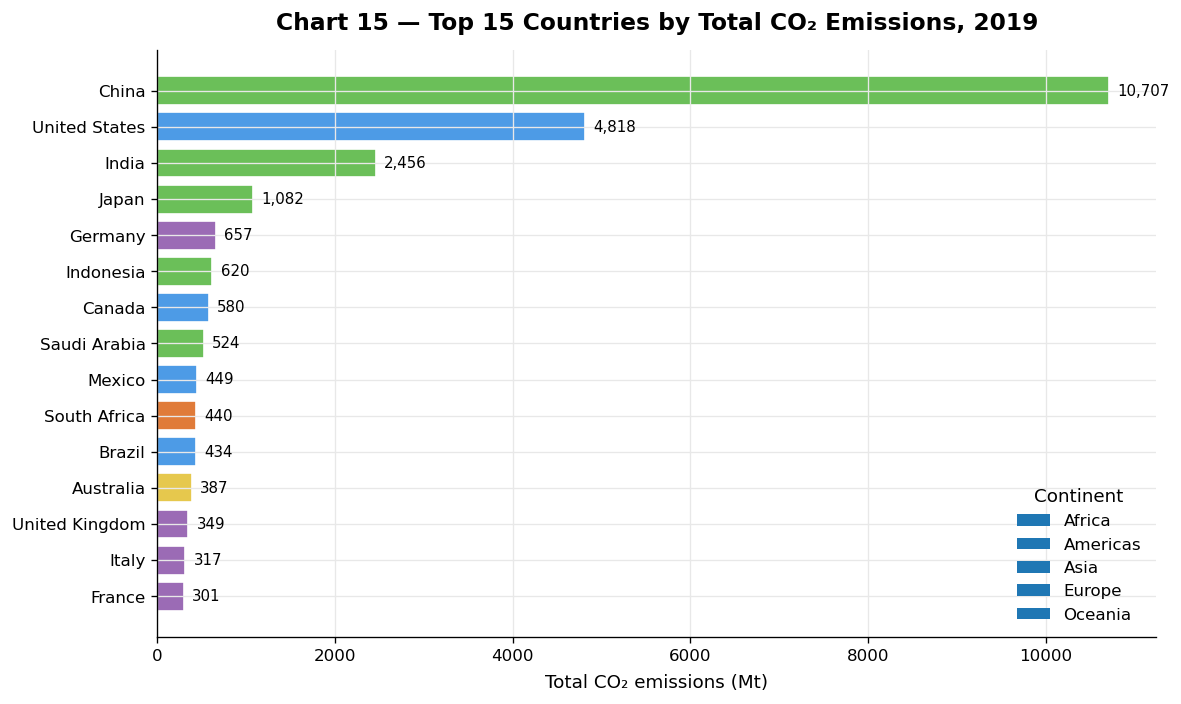

Saved: images/chart15_top15_co2.png


In [34]:
df_c15 = (
    df[df['year'] == 2019]
    .dropna(subset=['co2_emissions_kt'])
    .nlargest(15, 'co2_emissions_kt')
    .sort_values('co2_emissions_kt')
    .copy()
)
df_c15['co2_mt'] = df_c15['co2_emissions_kt'] / 1000

fig, ax = plt.subplots(figsize=(10, 6))
colors = [CONT_PALETTE[c] for c in df_c15['continent']]
bars = ax.barh(df_c15['country'], df_c15['co2_mt'], color=colors, edgecolor='white')
ax.bar_label(bars, labels=[f'{v:,.0f}' for v in df_c15['co2_mt']], padding=5, fontsize=9)
for cont in CONT_ORDER:
    if cont in df_c15['continent'].values:
        ax.barh([], [], color=CONT_PALETTE[cont], label=cont)

ax.legend(title='Continent', loc='lower right')
ax.set_xlabel('Total CO₂ emissions (Mt)')
ax.set_title('Chart 15 — Top 15 Countries by Total CO₂ Emissions, 2019')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/chart15_top15_co2.png')
plt.show()
print('Saved: images/chart15_top15_co2.png')

**Chart 16 — In 2019, does higher GDP per capita mean higher CO₂ per capita?**

Both axes use per-capita metrics for a consistent comparison. CO₂ per capita is derived in §1.8 using a static population proxy. Gulf states (Qatar, Kuwait, UAE) are high-emission outliers relative to their GDP; European countries cluster below the regression line, reflecting efficient energy use.

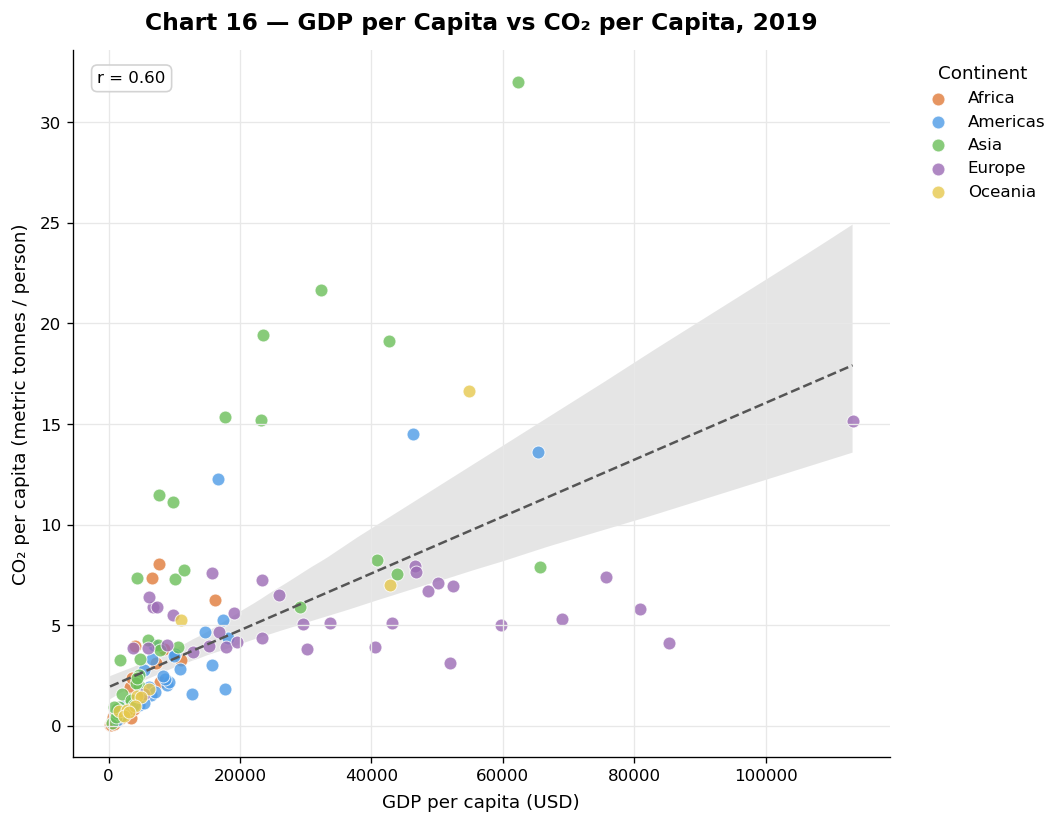

Saved: images/chart16_gdp_vs_co2.png


In [35]:
df_c16 = df[df['year'] == 2019].dropna(subset=['gdp_per_capita', 'co2_per_capita'])

fig, ax = plt.subplots(figsize=(9, 7))
sns.regplot(data=df_c16, x='gdp_per_capita', y='co2_per_capita',
            scatter=False, ax=ax,
            line_kws={'color': '#555555', 'lw': 1.5, 'linestyle': '--'})
for cont in CONT_ORDER:
    grp = df_c16[df_c16['continent'] == cont]
    ax.scatter(grp['gdp_per_capita'], grp['co2_per_capita'],
               color=CONT_PALETTE[cont], alpha=0.80, s=60, label=cont,
               edgecolors='white', linewidths=0.6)

r = np.corrcoef(df_c16['gdp_per_capita'], df_c16['co2_per_capita'])[0, 1]
ax.text(0.03, 0.97, f'r = {r:.2f}', transform=ax.transAxes,
        fontsize=10, va='top',
        bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='#CCCCCC', alpha=0.85))

ax.set_xlabel('GDP per capita (USD)')
ax.set_ylabel('CO₂ per capita (metric tonnes / person)')
ax.set_title('Chart 16 — GDP per Capita vs CO₂ per Capita, 2019')
ax.legend(title='Continent', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/chart16_gdp_vs_co2.png')
plt.show()
print('Saved: images/chart16_gdp_vs_co2.png')

**Chart 17 — In 2019, does higher GDP per capita mean higher primary energy consumption per capita?**

Both axes are per-capita and use 2019 data. The strong positive correlation confirms that richer economies consume more energy. Gulf states and Iceland are notable outliers — high energy use relative to their income level.

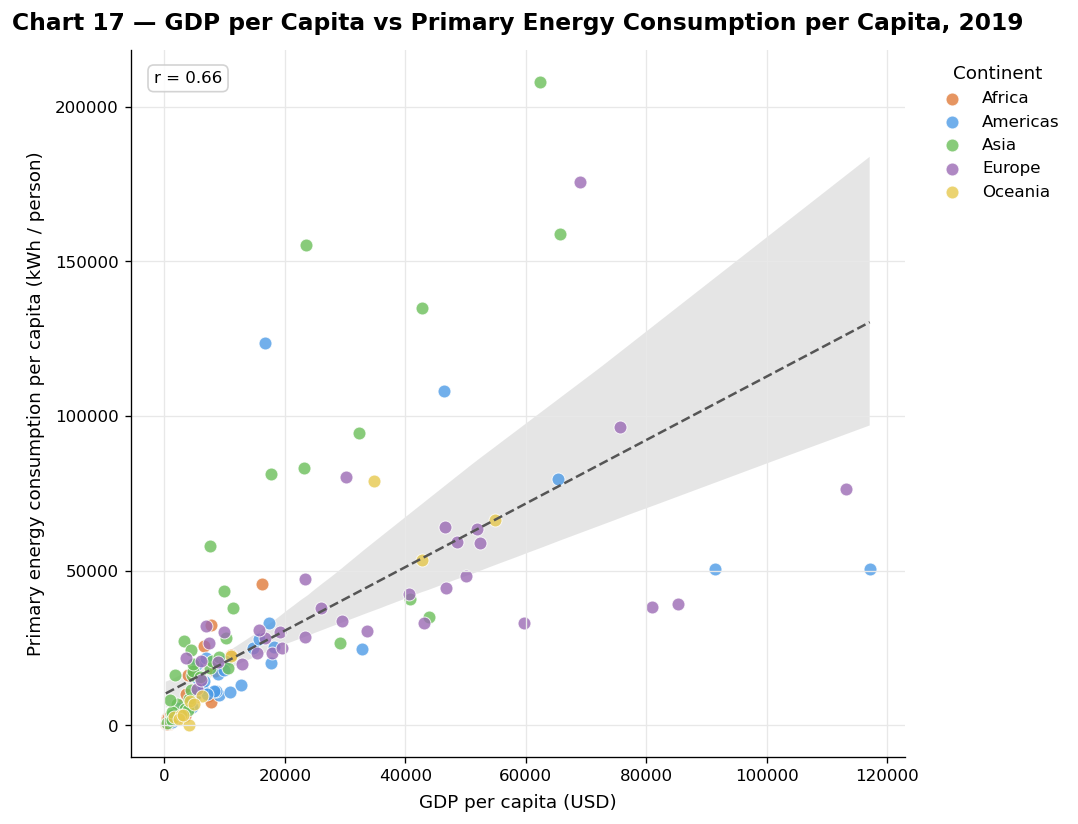

Saved: images/chart17_gdp_vs_energy.png


In [36]:
df_c17 = df[df['year'] == 2019].dropna(subset=['gdp_per_capita', 'primary_energy_per_capita'])

fig, ax = plt.subplots(figsize=(9, 7))
sns.regplot(data=df_c17, x='gdp_per_capita', y='primary_energy_per_capita',
            scatter=False, ax=ax,
            line_kws={'color': '#555555', 'lw': 1.5, 'linestyle': '--'})
for cont in CONT_ORDER:
    grp = df_c17[df_c17['continent'] == cont]
    ax.scatter(grp['gdp_per_capita'], grp['primary_energy_per_capita'],
               color=CONT_PALETTE[cont], alpha=0.80, s=60, label=cont,
               edgecolors='white', linewidths=0.6)

r = np.corrcoef(df_c17['gdp_per_capita'], df_c17['primary_energy_per_capita'])[0, 1]
ax.text(0.03, 0.97, f'r = {r:.2f}', transform=ax.transAxes,
        fontsize=10, va='top',
        bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='#CCCCCC', alpha=0.85))

ax.set_xlabel('GDP per capita (USD)')
ax.set_ylabel('Primary energy consumption per capita (kWh / person)')
ax.set_title('Chart 17 — GDP per Capita vs Primary Energy Consumption per Capita, 2019')
ax.legend(title='Continent', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/chart17_gdp_vs_energy.png')
plt.show()
print('Saved: images/chart17_gdp_vs_energy.png')

**Chart 18 — How has per-capita CO₂ by continent evolved from 2000 to 2019? Which continents have reduced emissions?**

Population is a static proxy in this dataset (see §1.8), so year-on-year changes reflect total CO₂ trends only. Europe shows a clear declining trend; Asia a sharp rise through ~2011 followed by a plateau; Oceania fluctuates; Africa remains low but slowly rising.

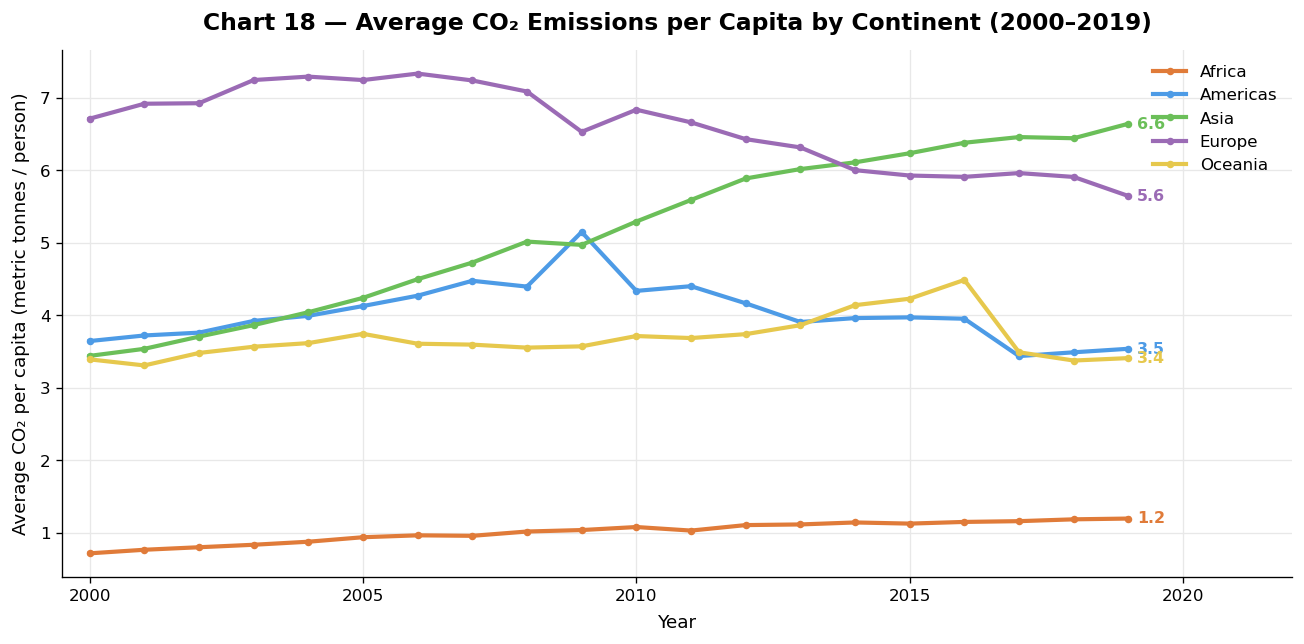

Saved: images/chart18_co2_per_capita_trend.png


In [37]:
co2_cont = (
    df[df['year'] <= 2019]
    .groupby(['year', 'continent'])['co2_per_capita']
    .mean().reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5.5))
for cont in CONT_ORDER:
    data = co2_cont[co2_cont['continent'] == cont]
    ax.plot(data['year'], data['co2_per_capita'],
            color=CONT_PALETTE[cont], lw=2.5, marker='o', ms=3.5, label=cont)
    val = data.loc[data['year'] == 2019, 'co2_per_capita'].values
    if len(val):
        ax.annotate(f'{val[0]:.1f}', xy=(2019, val[0]),
                    xytext=(5, 0), textcoords='offset points',
                    fontsize=9.5, color=CONT_PALETTE[cont], va='center', fontweight='bold')

ax.set_xlabel('Year')
ax.set_ylabel('Average CO₂ per capita (metric tonnes / person)')
ax.set_title('Chart 18 — Average CO₂ Emissions per Capita by Continent (2000–2019)')
ax.set_xlim(1999.5, 2022)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.legend(loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/chart18_co2_per_capita_trend.png')
plt.show()
print('Saved: images/chart18_co2_per_capita_trend.png')

**Chart 19 — Do countries with a higher renewable energy share have lower per-capita CO₂ in 2019?**

A negative correlation is expected — more renewable energy means less fossil-fuel combustion and lower emissions per person. However, correlation ≠ causation: controlling for GDP per capita would be needed to isolate the effect of the energy mix from overall development level.

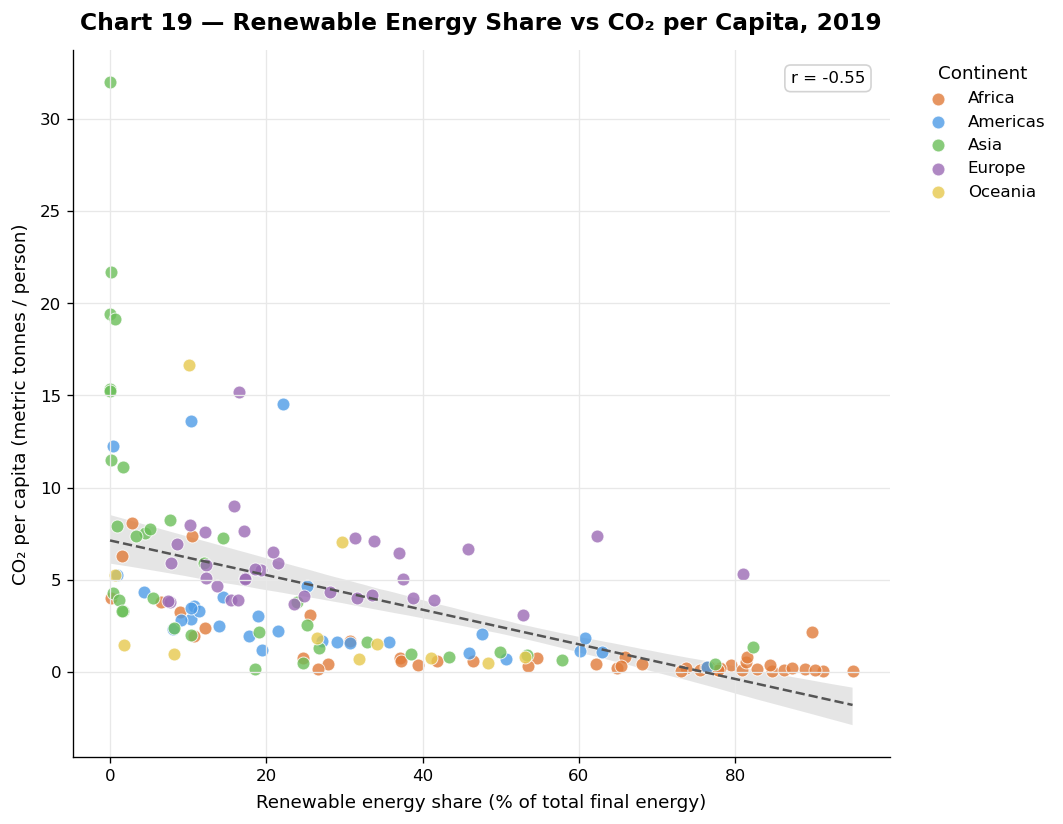

Saved: images/chart19_renew_vs_co2.png


In [38]:
df_c19 = df[df['year'] == 2019].dropna(subset=['renew_energy_share_pct', 'co2_per_capita'])

fig, ax = plt.subplots(figsize=(9, 7))
sns.regplot(data=df_c19, x='renew_energy_share_pct', y='co2_per_capita',
            scatter=False, ax=ax,
            line_kws={'color': '#555555', 'lw': 1.5, 'linestyle': '--'})
for cont in CONT_ORDER:
    grp = df_c19[df_c19['continent'] == cont]
    ax.scatter(grp['renew_energy_share_pct'], grp['co2_per_capita'],
               color=CONT_PALETTE[cont], alpha=0.80, s=60, label=cont,
               edgecolors='white', linewidths=0.6)

r = np.corrcoef(df_c19['renew_energy_share_pct'], df_c19['co2_per_capita'])[0, 1]
ax.text(0.97, 0.97, f'r = {r:.2f}', transform=ax.transAxes,
        fontsize=10, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='#CCCCCC', alpha=0.85))

ax.set_xlabel('Renewable energy share (% of total final energy)')
ax.set_ylabel('CO₂ per capita (metric tonnes / person)')
ax.set_title('Chart 19 — Renewable Energy Share vs CO₂ per Capita, 2019')
ax.legend(title='Continent', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/chart19_renew_vs_co2.png')
plt.show()
print('Saved: images/chart19_renew_vs_co2.png')

**Chart 20 — What is the overall pattern between per-capita GDP, energy use, and CO₂ in 2019?**

An interactive Plotly bubble chart: GDP per capita on x, CO₂ per capita on y, and primary energy per capita encoded as bubble size. Countries in the top-right cluster are rich, energy-intensive, and high-emitting. Clean-energy outliers — France, Switzerland, Sweden — achieve high GDP with below-expected CO₂, visible as they sit below the main cluster.

In [39]:
df_c20 = df[df['year'] == 2019].dropna(
    subset=['gdp_per_capita', 'co2_per_capita', 'primary_energy_per_capita']
)

fig = px.scatter(
    df_c20,
    x='gdp_per_capita',
    y='co2_per_capita',
    size='primary_energy_per_capita',
    color='continent',
    hover_name='country',
    color_discrete_map=CONT_PALETTE,
    category_orders={'continent': CONT_ORDER},
    size_max=55,
    title='Chart 20 — GDP per Capita, Energy Use, and CO₂ per Capita, 2019',
    labels={
        'gdp_per_capita':            'GDP per capita (USD)',
        'co2_per_capita':            'CO₂ per capita (t / person)',
        'primary_energy_per_capita': 'Energy per capita (kWh)',
        'continent':                 'Continent',
    },
)
fig.update_traces(marker=dict(opacity=0.80, line=dict(width=0.5, color='white')))
fig.update_layout(
    margin=dict(l=40, r=40, t=60, b=40),
    height=560,
    title_font_size=15,
    title_x=0.5,
    legend=dict(title='Continent', yanchor='top', y=0.98, xanchor='left', x=1.01),
)
fig.write_html('images/chart20_gdp_energy_co2_bubble.html')
print('Saved: images/chart20_gdp_energy_co2_bubble.html')
fig.show()

Saved: images/chart20_gdp_energy_co2_bubble.html
